# FarmTech Solutions — Fase 5, Entrega 1
## Análise exploratória, clusterização, outliers e regressão do rendimento de safra

**Status deste notebook: versão de desenvolvimento (Etapa 1), executada de ponta a ponta.**

> ✅ **Notebook renomeado conforme o enunciado.** Nome completo, RM e o sufixo `pbl_fase4.ipynb`
> aplicados: `MatheusFontes_rm570457_pbl_fase4.ipynb`.

### O que este notebook cobre

| Seção | Conteúdo | Situação |
| --- | --- | --- |
| 1 | Ambiente, semente e caminhos | executado |
| 2 | Carga, integridade e inventário da base | executado |
| 3 | Contrato de dados e identificador de cenário | executado |
| 4 | Divisão treino/teste por cenário e validação cruzada agrupada | executado |
| 5 | Análise exploratória (EDA) | executado |
| 6 | Clusterização de cenários climáticos | executado |
| 7 | Investigação de outliers | executado |
| 8 | Comparação dos cinco regressores (validação aninhada) | executado |
| 9 | Avaliação no teste reservado | executado (ver seção 9.1) |
| 10 | Conclusões, limitações e pendências | executado |

### Decisões metodológicas em linguagem simples

1. **Cada combinação climática aparece quatro vezes na base**, uma vez por cultura. Se essas
   quatro linhas fossem separadas entre treino e teste, o modelo veria no treino exatamente as
   mesmas condições de clima que encontraria no teste. Para medir se o modelo generaliza para
   condições climáticas novas, mantemos cada combinação inteira de um lado só da divisão.
2. **A cultura responde por quase toda a variação do rendimento.** O dendê rende cerca de vinte
   vezes mais, nas unidades do arquivo, do que o cacau. Por isso um R² alto no conjunto todo não é
   suficiente, isoladamente, para julgar um modelo: ele pode refletir apenas a distinção entre
   culturas. A pergunta que interessa é se o clima acrescenta informação **dentro de cada cultura**,
   comparada a uma referência que só usa a cultura — e é assim que comparamos os modelos.
3. **Não convertemos unidades.** O enunciado descreve o rendimento em toneladas por hectare,
   mas os valores do CSV (de 5.249 a 203.399) não são compatíveis com essa leitura. Mantemos os
   números originais e reportamos os erros na mesma unidade do arquivo, sem adotar nenhuma hipótese
   de unidade. Ver seção 3.3.
4. **A busca de hiperparâmetros acontece dentro do treino de cada partição** (validação cruzada
   aninhada). Se os mesmos dados escolhessem os parâmetros e depois medissem o resultado dessa
   escolha, a métrica sairia otimista. Ver seção 8.1.

In [1]:
# ============================================================
# 1. AMBIENTE, SEMENTE E CAMINHOS
# ============================================================
import hashlib          # hash SHA-256 para verificar a integridade do CSV
import json             # serializacao do registro do protocolo
import sys              # versao do interpretador Python
import warnings         # controle das mensagens de aviso
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

# Semente unica do projeto: todo procedimento aleatorio que aceite semente usa esta constante.
SEED = 42
np.random.seed(SEED)

# Silencia apenas avisos de conveniencia de bibliotecas; erros continuam visiveis.
warnings.filterwarnings("ignore", category=FutureWarning)

# Padroes de exibicao para que as tabelas caibam na largura da pagina.
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

print("Python      ", sys.version.split()[0])
print("numpy       ", np.__version__)
print("pandas      ", pd.__version__)
print("scikit-learn", sklearn.__version__)
print("matplotlib  ", matplotlib.__version__)
print("seaborn     ", sns.__version__)

Python       3.13.5
numpy        2.3.3
pandas       2.3.2
scikit-learn 1.7.1
matplotlib   3.10.6
seaborn      0.13.2


In [2]:
def encontrar_raiz(inicio=None):
    """Sobe na arvore de diretorios ate achar a pasta que contem data/crop_yield.csv.

    Assim o notebook funciona tanto executado de dentro de notebooks/ quanto da raiz
    do projeto, sempre com caminhos relativos.
    """
    atual = Path(inicio or Path.cwd()).resolve()
    for candidato in [atual, *atual.parents]:
        if (candidato / "data" / "crop_yield.csv").exists():
            return candidato
    raise FileNotFoundError("data/crop_yield.csv nao encontrado a partir de " + str(atual))


RAIZ = encontrar_raiz()                           # raiz do projeto
CAMINHO_CSV = RAIZ / "data" / "crop_yield.csv"    # base original, nunca sobrescrita
DIR_FIGURAS = RAIZ / "docs" / "figuras"           # destino das figuras exportadas
DIR_FIGURAS.mkdir(parents=True, exist_ok=True)

print("Raiz do projeto:", RAIZ)
print("CSV            :", CAMINHO_CSV.relative_to(RAIZ))
print("Figuras        :", DIR_FIGURAS.relative_to(RAIZ))

Raiz do projeto: C:\Users\fonte\OneDrive\Documentos\Fiap\Fase 2 - 2026\proejto2\fase5-cap1-farmtech
CSV            : data\crop_yield.csv
Figuras        : docs\figuras


In [3]:
# Estilo visual unico para todas as figuras do notebook.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,                       # legibilidade na tela
    "savefig.dpi": 150,                      # qualidade dos arquivos exportados
    "figure.constrained_layout.use": True,   # evita rotulos cortados
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "font.size": 10,
})

# Paleta fixa por cultura, usada em todas as figuras para facilitar a leitura comparada.
CORES_CULTURA = {
    "Cocoa, beans":    "#8C6239",   # marrom
    "Oil palm fruit":  "#E1A100",   # ambar
    "Rice, paddy":     "#2E8B57",   # verde
    "Rubber, natural": "#4C6EF5",   # azul
}

# Rotulos curtos para os eixos, evitando texto cortado nas figuras.
ROTULO_CURTO = {
    "Cocoa, beans": "Cacau",
    "Oil palm fruit": "Dende",
    "Rice, paddy": "Arroz",
    "Rubber, natural": "Borracha",
}

ROTULO_CLIMA = {
    "precipitacao": "Precipitacao",
    "umidade_especifica": "Umidade especifica",
    "umidade_relativa": "Umidade relativa",
    "temperatura": "Temperatura",
}


def salvar_figura(fig, nome):
    """Exporta a figura para docs/figuras/ com margem folgada, para reuso no README e no video."""
    destino = DIR_FIGURAS / (nome + ".png")
    fig.savefig(destino, bbox_inches="tight", facecolor="white")
    print("figura salva:", destino.relative_to(RAIZ))

---
# 2. Carga, verificação de integridade e inventário

O CSV original permanece intacto em `data/crop_yield.csv`. Registramos o hash SHA-256 do arquivo
para que qualquer integrante confirme que está trabalhando exatamente sobre a mesma base.

In [4]:
# ============================================================
# 2. CARGA E VERIFICACAO DE INTEGRIDADE
# ============================================================
BYTES_CSV = CAMINHO_CSV.read_bytes()                       # leitura binaria para o hash
HASH_CSV = hashlib.sha256(BYTES_CSV).hexdigest().upper()   # impressao digital do arquivo
HASH_ESPERADO = "07B3335F497E08E705B5835EE334426AC16CB24732C1BFAA994254D39F771B1B"

bruto = pd.read_csv(CAMINHO_CSV)   # DataFrame com os nomes de coluna originais

print("SHA-256 do arquivo :", HASH_CSV)
print("SHA-256 esperado   :", HASH_ESPERADO)
print("Integridade        :", "OK" if HASH_CSV == HASH_ESPERADO else "DIVERGENTE - conferir a origem do CSV")
print("")
print("Dimensoes          :", bruto.shape[0], "linhas x", bruto.shape[1], "colunas")
print("Tamanho            :", format(len(BYTES_CSV), ","), "bytes")
print("")
print("Colunas originais:")
for i, coluna in enumerate(bruto.columns, start=1):
    print("  " + str(i) + ".", coluna)

SHA-256 do arquivo : 07B3335F497E08E705B5835EE334426AC16CB24732C1BFAA994254D39F771B1B
SHA-256 esperado   : 07B3335F497E08E705B5835EE334426AC16CB24732C1BFAA994254D39F771B1B
Integridade        : OK

Dimensoes          : 156 linhas x 6 colunas
Tamanho            : 7,606 bytes

Colunas originais:
  1. Crop
  2. Precipitation (mm day-1)
  3. Specific Humidity at 2 Meters (g/kg)
  4. Relative Humidity at 2 Meters (%)
  5. Temperature at 2 Meters (C)
  6. Yield


In [5]:
# Inventario de qualidade: tipos, nulos, valores distintos e amostra de valores.
inventario = pd.DataFrame({
    "tipo": bruto.dtypes.astype(str),
    "nao_nulos": bruto.notna().sum(),
    "nulos": bruto.isna().sum(),
    "distintos": bruto.nunique(),
    "exemplo": [bruto[c].iloc[0] for c in bruto.columns],
})
print("=== Inventario das colunas ===")
display(inventario)

# Duplicatas: linhas identicas em todas as colunas.
print("")
print("Linhas completamente duplicadas:", int(bruto.duplicated().sum()))
print("Total de celulas vazias        :", int(bruto.isna().sum().sum()))

=== Inventario das colunas ===


,tipo,nao_nulos,nulos,distintos,exemplo
Crop,object,156,0,4,"Cocoa, beans"
Precipitation (mm day-1),float64,156,0,39,2248.92
Specific Humidity at 2 Meters (g/kg),float64,156,0,33,17.72
Relative Humidity at 2 Meters (%),float64,156,0,38,83.4
Temperature at 2 Meters (C),float64,156,0,29,26.01
Yield,int64,156,0,155,11560



Linhas completamente duplicadas: 0
Total de celulas vazias        : 0


### 2.1 Achados do inventário

- **156 linhas e 6 colunas**, sem nenhuma célula vazia e sem nenhuma linha completamente duplicada.
- Uma coluna categórica (`Crop`), quatro colunas climáticas numéricas e a coluna alvo `Yield`.
- **Não existe coluna de data, de local nem de identificação de fazenda.** Portanto não é possível
  afirmar que os registros correspondem a anos, safras ou talhões específicos. Qualquer leitura
  temporal seria suposição nossa, não informação da base.

---
# 3. Contrato de dados

Esta seção implementa o mesmo protocolo descrito em [`docs/CONTRATO_DADOS.md`](../docs/CONTRATO_DADOS.md).
Ele existe para que a frente ML reproduza exatamente a mesma divisão e as mesmas partições ao
desenvolver os modelos, e para que o restante do grupo saiba o que cada nome interno significa.

In [6]:
# ============================================================
# 3. CONTRATO DE DADOS
# ============================================================
# Mapeamento dos nomes originais do CSV para nomes internos curtos e sem acento.
RENOMEAR = {
    "Crop": "cultura",
    "Precipitation (mm day-1)": "precipitacao",
    "Specific Humidity at 2 Meters (g/kg)": "umidade_especifica",
    "Relative Humidity at 2 Meters (%)": "umidade_relativa",
    "Temperature at 2 Meters (C)": "temperatura",
    "Yield": "rendimento",
}

VAR_CLIMA = ["precipitacao", "umidade_especifica", "umidade_relativa", "temperatura"]  # entradas numericas
VAR_CATEGORICA = ["cultura"]     # entrada categorica
ALVO = "rendimento"              # variavel a prever

dados = bruto.rename(columns=RENOMEAR).copy()   # copia de trabalho; o CSV original nao e alterado

# Dicionario de dados exibido no relatorio.
dicionario = pd.DataFrame([
    ("Crop", "cultura", "categorica", "-", "Nome da cultura agricola. 4 categorias."),
    ("Precipitation (mm day-1)", "precipitacao", "numerica", "mm/dia (declarada)", "Chuva. Ver duvida de unidade em 3.3."),
    ("Specific Humidity at 2 Meters (g/kg)", "umidade_especifica", "numerica", "g/kg", "Vapor de agua por kg de ar seco a 2 m."),
    ("Relative Humidity at 2 Meters (%)", "umidade_relativa", "numerica", "%", "Umidade relativa a 2 m."),
    ("Temperature at 2 Meters (C)", "temperatura", "numerica", "graus C", "Temperatura do ar a 2 m."),
    ("Yield", "rendimento", "numerica", "t/ha (declarada)", "ALVO. Ver duvida de unidade em 3.3."),
], columns=["nome_original", "nome_interno", "tipo", "unidade_declarada", "descricao"])
display(dicionario)

,nome_original,nome_interno,tipo,unidade_declarada,descricao
0,Crop,cultura,categorica,-,Nome da cultura agricola. 4 categorias.
1,Precipitation (mm day-1),precipitacao,numerica,mm/dia (declarada),Chuva. Ver duvida de unidade em 3.3.
2,Specific Humidity at 2 Meters (g/kg),umidade_especifica,numerica,g/kg,Vapor de agua por kg de ar seco a 2 m.
3,Relative Humidity at 2 Meters (%),umidade_relativa,numerica,%,Umidade relativa a 2 m.
4,Temperature at 2 Meters (C),temperatura,numerica,graus C,Temperatura do ar a 2 m.
5,Yield,rendimento,numerica,t/ha (declarada),ALVO. Ver duvida de unidade em 3.3.


## 3.1 Estrutura escondida da base: cada cenário climático aparece quatro vezes

Antes de qualquer modelagem é preciso entender como as linhas se relacionam entre si. A verificação
abaixo mostra que as quatro variáveis climáticas formam apenas **39 combinações distintas**, e que
cada combinação aparece **exatamente quatro vezes** — uma vez para cada cultura.

In [7]:
def identificador_cenario(linha):
    """Gera um identificador deterministico a partir apenas das quatro variaveis climaticas.

    O identificador NAO usa a cultura nem o rendimento: ele serve para agrupar linhas que
    descrevem a mesma condicao climatica. E usado para dividir os dados, nunca como entrada
    do modelo. O arredondamento fixo em 6 casas garante o mesmo resultado em qualquer maquina.
    """
    assinatura = "|".join(format(linha[variavel], ".6f") for variavel in VAR_CLIMA)
    return hashlib.sha256(assinatura.encode("utf-8")).hexdigest()[:12]


dados["cenario"] = dados.apply(identificador_cenario, axis=1)

print("Cenarios climaticos distintos :", dados["cenario"].nunique())
print("Linhas por cenario            :", sorted(dados.groupby("cenario").size().unique().tolist()))
print("Culturas por cenario          :", sorted(dados.groupby("cenario")["cultura"].nunique().unique().tolist()))
print("Linhas por cultura            :", dados["cultura"].value_counts().to_dict())

Cenarios climaticos distintos : 39
Linhas por cenario            : [4]
Culturas por cenario          : [4]
Linhas por cultura            : {'Cocoa, beans': 39, 'Oil palm fruit': 39, 'Rice, paddy': 39, 'Rubber, natural': 39}


### 3.2 Por que essa repetição não é duplicata a remover

As quatro linhas de um mesmo cenário **não são cópias**: elas têm rendimentos diferentes, porque
descrevem culturas diferentes sob a mesma condição climática. Remover três delas destruiria a
informação central do problema.

O que a repetição significa para a avaliação é outra coisa: **a base descreve apenas 39 cenários
climáticos distintos, ainda que tenha 156 linhas**. Se dividíssemos as linhas ao acaso, o modelo
veria no treino exatamente o mesmo clima que encontraria no teste, mudando só a cultura. A métrica
resultante mediria a capacidade de memorizar 39 cenários, não a de generalizar para um clima novo.

A base não traz data, local nem identificação de origem, então **não é possível verificar se esses
39 cenários são observações estatisticamente independentes entre si** — eles podem, por exemplo,
vir de anos consecutivos da mesma região. Por isso usamos "cenários distintos", e não
"observações independentes": o que se sabe é que são combinações climáticas diferentes.

Por isso adotamos a divisão **por cenário**: cada combinação climática fica inteira em treino ou
inteira em teste.

### 3.3 Dúvida sobre unidades — pendência aberta com a FIAP

O enunciado declara que `Yield` está em **toneladas por hectare**. Os valores do CSV vão de
**5.249 a 203.399**. Uma produtividade de 200 mil toneladas por hectare não tem sentido agronômico
(o dendê, uma das culturas mais produtivas, fica na casa de 10 a 25 t/ha).

O mesmo vale para a precipitação: `Precipitation (mm day-1)` sugere milímetros por dia, mas os
valores vão de **1.934 a 3.086** — uma chuva de 3.000 mm em um único dia não é plausível.

Portanto há uma diferença entre a **unidade declarada no enunciado** e a **unidade efetiva do
arquivo, que não foi verificada**. Não sabemos qual é a unidade real, e **não vamos supor uma**:
qualquer palpite aqui viraria um número no relatório.

**Como tratamos isso neste notebook:**

- Mantemos os valores originais, **sem nenhuma conversão**.
- Reportamos MAE e RMSE **na unidade original do arquivo**, escrita como "un. de rendimento".
- Incluímos o **erro percentual (MAPE)**, que não depende da escala e permite comparar culturas com
  magnitudes muito diferentes.
- **Não** escrevemos "t/ha" ao lado das métricas enquanto a unidade não for confirmada.

**O que muda quando a unidade for esclarecida.** Depende do que a confirmação exigir:

| Situação | Efeito |
| --- | --- |
| A unidade é apenas **renomeada** (os números do arquivo já estão certos) | Muda só o texto; nenhum número muda. |
| Os valores precisam ser **convertidos por um fator constante** (por exemplo, dividir por 10.000) | **MAE e RMSE mudam** na mesma proporção, e as escalas dos eixos dos gráficos também. **R² e MAPE não mudam**, por serem invariantes a uma multiplicação consistente de observados e previstos. A ordem entre as alternativas se mantém. |
| A correção altera os **dados usados no treino** (e não apenas a escala de saída) | É preciso revisar as transformações e os parâmetros sensíveis à escala — o SVR e a variante com log do alvo, em particular — e reexecutar a comparação. |

> **Pendência do coordenador:** confirmar com a FIAP a unidade real de `Yield` e de
> `Precipitation`, e se os 39 cenários correspondem a alguma agregação temporal. Enquanto não houver
> confirmação, a pendência permanece aberta e nenhuma hipótese de unidade é adotada.

---
# 4. Divisão treino/teste e validação cruzada agrupada

**Regra fundamental deste projeto:** a divisão é fixada *antes* de qualquer análise orientada pelo
alvo. Tudo o que orienta escolhas preditivas (correlações com o rendimento, clusters, seleção de
modelo, hiperparâmetros) usa **somente o conjunto de desenvolvimento**. O conjunto de teste fica
lacrado até o fechamento, após a revisão da equipe.

In [8]:
# ============================================================
# 4. DIVISAO POR CENARIO
# ============================================================
from sklearn.model_selection import GroupKFold, GroupShuffleSplit

# GroupShuffleSplit reserva 20% dos GRUPOS (cenarios), nao 20% das linhas.
separador = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
idx_desenvolvimento, idx_teste = next(separador.split(dados, groups=dados["cenario"]))

desenvolvimento = dados.iloc[idx_desenvolvimento].reset_index(drop=True)  # usado em TUDO nesta etapa
teste = dados.iloc[idx_teste].reset_index(drop=True)                      # lacrado ate o fechamento

print("=== Divisao por cenario (GroupShuffleSplit, test_size=0.20, random_state=42) ===")
print("Desenvolvimento :", len(desenvolvimento), "linhas |", desenvolvimento["cenario"].nunique(), "cenarios")
print("Teste reservado :", len(teste), "linhas |", teste["cenario"].nunique(), "cenarios")
print("")
print("Culturas no desenvolvimento:", desenvolvimento["cultura"].value_counts().to_dict())
print("Culturas no teste          :", teste["cultura"].value_counts().to_dict())

=== Divisao por cenario (GroupShuffleSplit, test_size=0.20, random_state=42) ===
Desenvolvimento : 124 linhas | 31 cenarios
Teste reservado : 32 linhas | 8 cenarios

Culturas no desenvolvimento: {'Cocoa, beans': 31, 'Oil palm fruit': 31, 'Rice, paddy': 31, 'Rubber, natural': 31}
Culturas no teste          : {'Cocoa, beans': 8, 'Oil palm fruit': 8, 'Rice, paddy': 8, 'Rubber, natural': 8}


In [9]:
# Particoes internas de validacao, definidas SOMENTE sobre o desenvolvimento.
# Todos os algoritmos usarao exatamente estas mesmas particoes.
validacao_cruzada = GroupKFold(n_splits=5)
PARTICOES = list(validacao_cruzada.split(
    desenvolvimento,
    desenvolvimento[ALVO],
    groups=desenvolvimento["cenario"],
))

resumo_particoes = pd.DataFrame([
    {
        "particao": i,
        "linhas_treino": len(tr),
        "linhas_validacao": len(va),
        "cenarios_treino": desenvolvimento.iloc[tr]["cenario"].nunique(),
        "cenarios_validacao": desenvolvimento.iloc[va]["cenario"].nunique(),
    }
    for i, (tr, va) in enumerate(PARTICOES)
])
display(resumo_particoes)

,particao,linhas_treino,linhas_validacao,cenarios_treino,cenarios_validacao
0,0,96,28,24,7
1,1,100,24,25,6
2,2,100,24,25,6
3,3,100,24,25,6
4,4,100,24,25,6


In [10]:
# ------------------------------------------------------------
# Verificacoes de vazamento - devem TODAS passar.
# ------------------------------------------------------------
verificacoes = []

# (a) nenhum cenario aparece ao mesmo tempo em desenvolvimento e teste
comuns = set(desenvolvimento["cenario"]) & set(teste["cenario"])
verificacoes.append(("Nenhum cenario compartilhado entre desenvolvimento e teste",
                     len(comuns) == 0, str(len(comuns)) + " em comum"))

# (b) nenhum cenario aparece ao mesmo tempo em treino e validacao, em nenhuma particao
vazamentos = [len(set(desenvolvimento.iloc[tr]["cenario"]) & set(desenvolvimento.iloc[va]["cenario"]))
              for tr, va in PARTICOES]
verificacoes.append(("Nenhum cenario compartilhado entre treino e validacao",
                     sum(vazamentos) == 0, "por particao: " + str(vazamentos)))

# (c) a soma das partes reproduz a base completa
verificacoes.append(("Desenvolvimento + teste = 156 linhas",
                     len(desenvolvimento) + len(teste) == len(dados),
                     str(len(desenvolvimento)) + " + " + str(len(teste))))

# (d) cada linha do desenvolvimento e validada exatamente uma vez
cobertura = np.zeros(len(desenvolvimento), dtype=int)
for _, va in PARTICOES:
    cobertura[va] += 1
verificacoes.append(("Cada linha validada exatamente 1 vez",
                     bool((cobertura == 1).all()), "contagens: " + str(sorted(set(cobertura.tolist())))))

# (e) as quatro culturas estao presentes em todas as particoes de validacao
culturas_ok = all(desenvolvimento.iloc[va]["cultura"].nunique() == 4 for _, va in PARTICOES)
verificacoes.append(("As 4 culturas aparecem em toda particao de validacao", culturas_ok, ""))

# (f) o CSV original continua com o hash esperado
verificacoes.append(("CSV original preservado (SHA-256)", HASH_CSV == HASH_ESPERADO, HASH_CSV[:16] + "..."))

tabela_verificacoes = pd.DataFrame(verificacoes, columns=["verificacao", "passou", "detalhe"])
tabela_verificacoes["passou"] = tabela_verificacoes["passou"].map({True: "OK", False: "FALHOU"})
display(tabela_verificacoes)

assert not (tabela_verificacoes["passou"] == "FALHOU").any(), "Alguma verificacao de protocolo falhou."
print("Todas as verificacoes de protocolo passaram.")

,verificacao,passou,detalhe
0,Nenhum cenario compartilhado entre desenvolvim...,OK,0 em comum
1,Nenhum cenario compartilhado entre treino e va...,OK,"por particao: [0, 0, 0, 0, 0]"
2,Desenvolvimento + teste = 156 linhas,OK,124 + 32
3,Cada linha validada exatamente 1 vez,OK,contagens: [1]
4,As 4 culturas aparecem em toda particao de val...,OK,
5,CSV original preservado (SHA-256),OK,07B3335F497E08E7...


Todas as verificacoes de protocolo passaram.


In [11]:
# Registro do protocolo em disco: permite que a frente ML confirme que reproduziu a mesma divisao.
registro_protocolo = {
    "arquivo_dados": "data/crop_yield.csv",
    "sha256_dados": HASH_CSV,
    "semente": SEED,
    "n_linhas": int(len(dados)),
    "n_cenarios": int(dados["cenario"].nunique()),
    "divisao": "GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42), agrupado por 'cenario'",
    "validacao": "GroupKFold(n_splits=5) aplicado somente ao desenvolvimento, agrupado por 'cenario'",
    "desenvolvimento": {"linhas": int(len(desenvolvimento)), "cenarios": int(desenvolvimento["cenario"].nunique())},
    "teste": {"linhas": int(len(teste)), "cenarios": int(teste["cenario"].nunique())},
    "cenarios_teste": sorted(teste["cenario"].unique().tolist()),
    "versoes": {"python": sys.version.split()[0], "numpy": np.__version__,
                "pandas": pd.__version__, "scikit-learn": sklearn.__version__},
}
destino_protocolo = RAIZ / "docs" / "protocolo_divisao.json"
destino_protocolo.write_text(json.dumps(registro_protocolo, indent=2, ensure_ascii=False), encoding="utf-8")
print("Protocolo registrado em:", destino_protocolo.relative_to(RAIZ))
print(json.dumps({k: v for k, v in registro_protocolo.items() if k != "cenarios_teste"},
                 indent=2, ensure_ascii=False))

Protocolo registrado em: docs\protocolo_divisao.json
{
  "arquivo_dados": "data/crop_yield.csv",
  "sha256_dados": "07B3335F497E08E705B5835EE334426AC16CB24732C1BFAA994254D39F771B1B",
  "semente": 42,
  "n_linhas": 156,
  "n_cenarios": 39,
  "divisao": "GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42), agrupado por 'cenario'",
  "validacao": "GroupKFold(n_splits=5) aplicado somente ao desenvolvimento, agrupado por 'cenario'",
  "desenvolvimento": {
    "linhas": 124,
    "cenarios": 31
  },
  "teste": {
    "linhas": 32,
    "cenarios": 8
  },
  "versoes": {
    "python": "3.13.5",
    "numpy": "2.3.3",
    "pandas": "2.3.2",
    "scikit-learn": "1.7.1"
  }
}


---
# 5. Análise exploratória (EDA)

Todas as análises desta seção usam **apenas o conjunto de desenvolvimento** (124 linhas,
31 cenários), porque orientam escolhas preditivas. Onde uma estatística descritiva da base
completa for citada, isso está explicitado no texto.

## 5.1 Estatísticas descritivas

In [12]:
# ============================================================
# 5. ANALISE EXPLORATORIA (somente desenvolvimento)
# ============================================================
print("Conjunto usado nesta secao: DESENVOLVIMENTO -",
      len(desenvolvimento), "linhas,", desenvolvimento["cenario"].nunique(), "cenarios")

estatisticas = desenvolvimento[VAR_CLIMA + [ALVO]].describe().T
estatisticas["amplitude"] = estatisticas["max"] - estatisticas["min"]
estatisticas["cv_%"] = (estatisticas["std"] / estatisticas["mean"] * 100)
display(estatisticas.round(2))

Conjunto usado nesta secao: DESENVOLVIMENTO - 124 linhas, 31 cenarios


,count,mean,std,min,25%,50%,75%,max,amplitude,cv_%
precipitacao,124.0,2475.60,257.84,1934.62,2302.99,2424.55,2686.20,2938.29,1003.67,10.42
umidade_especifica,124.0,18.21,0.25,17.61,18.09,18.24,18.38,18.70,1.09,1.38
umidade_relativa,124.0,84.76,0.90,82.79,84.23,84.85,85.45,86.09,3.30,1.06
temperatura,124.0,26.19,0.25,25.56,26.02,26.18,26.30,26.79,1.23,0.94
rendimento,124.0,55329.17,69419.66,5249.00,8170.00,18123.00,67518.75,203399.00,198150.00,125.47


**Leitura.** As quatro variáveis climáticas variam pouco: a temperatura fica entre 25,6 e 26,8 °C
(coeficiente de variação de cerca de 1%) e a umidade relativa entre 82 e 86%. A precipitação é a
única com dispersão apreciável (cerca de 11%). O rendimento, ao contrário, tem coeficiente de
variação acima de 100% — mas isso vem quase todo da mistura de culturas, como a próxima subseção mostra.

Ou seja: **a base descreve um único regime climático tropical úmido, observado com pequenas
variações.** Isso limita desde já o que qualquer modelo pode aprender sobre o efeito do clima.

## 5.2 Rendimento por cultura: a variação dominante

In [13]:
# Estatisticas do rendimento separadas por cultura.
por_cultura = desenvolvimento.groupby("cultura")[ALVO].agg(
    n="size", minimo="min", mediana="median", media="mean", maximo="max", desvio="std"
)
por_cultura["cv_%"] = (por_cultura["desvio"] / por_cultura["media"] * 100).round(1)
por_cultura["razao_max_min"] = (por_cultura["maximo"] / por_cultura["minimo"]).round(2)
display(por_cultura.round(0))

# Qual fracao da variancia total do rendimento e explicada apenas por saber a cultura?
media_geral = desenvolvimento[ALVO].mean()
sq_total = ((desenvolvimento[ALVO] - media_geral) ** 2).sum()
medias_cultura = desenvolvimento.groupby("cultura")[ALVO].transform("mean")
sq_residual = ((desenvolvimento[ALVO] - medias_cultura) ** 2).sum()
eta2 = 1 - sq_residual / sq_total

print("")
print("Variancia do rendimento explicada SO pela cultura (eta^2): {:.4f}".format(eta2))
print("Ou seja, {:.1f}% da variacao do rendimento vem da diferenca entre culturas,".format(eta2 * 100))
print("e apenas {:.1f}% resta para o clima e para tudo o mais explicar.".format((1 - eta2) * 100))

,n,minimo,mediana,media,maximo,desvio,cv_%,razao_max_min
cultura,,,,,,,,
"Cocoa, beans",31,5765,8300.0,8549.0,11560,1494.0,18.0,2.0
Oil palm fruit,31,142425,169783.0,173142.0,203399,14747.0,8.0,1.0
"Rice, paddy",31,24686,30676.0,31916.0,42550,4735.0,15.0,2.0
"Rubber, natural",31,5249,6913.0,7711.0,10285,1672.0,22.0,2.0



Variancia do rendimento explicada SO pela cultura (eta^2): 0.9876
Ou seja, 98.8% da variacao do rendimento vem da diferenca entre culturas,
e apenas 1.2% resta para o clima e para tudo o mais explicar.


figura salva: docs\figuras\fig01_rendimento_por_cultura.png


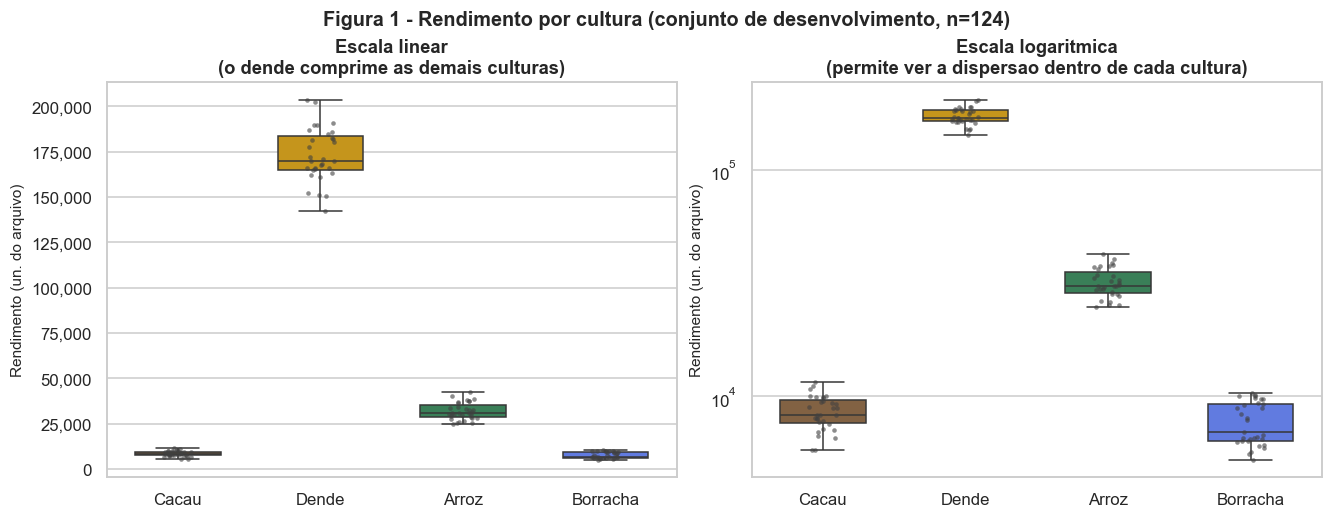

In [14]:
# Figura 1: distribuicao do rendimento por cultura, em escala linear e logaritmica.
fig, eixos = plt.subplots(1, 2, figsize=(12, 4.6))
ordem = list(CORES_CULTURA.keys())
paleta = [CORES_CULTURA[c] for c in ordem]

for eixo, log in zip(eixos, [False, True]):
    sns.boxplot(data=desenvolvimento, x="cultura", y=ALVO, order=ordem,
                hue="cultura", palette=paleta, legend=False, width=0.6, ax=eixo)
    sns.stripplot(data=desenvolvimento, x="cultura", y=ALVO, order=ordem,
                  color="0.25", size=3, alpha=0.6, ax=eixo)
    eixo.set_xticks(range(len(ordem)))
    eixo.set_xticklabels([ROTULO_CURTO[c] for c in ordem])
    eixo.set_xlabel("")
    eixo.set_ylabel("Rendimento (un. do arquivo)")
    if log:
        eixo.set_yscale("log")
        eixo.set_title("Escala logaritmica\n(permite ver a dispersao dentro de cada cultura)")
    else:
        eixo.set_title("Escala linear\n(o dende comprime as demais culturas)")
        eixo.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter("{x:,.0f}"))

fig.suptitle("Figura 1 - Rendimento por cultura (conjunto de desenvolvimento, n=124)",
             fontsize=13, fontweight="bold")
salvar_figura(fig, "fig01_rendimento_por_cultura")
plt.show()

**Leitura da Figura 1.** Na escala linear, as três culturas menores viram uma faixa achatada perto
do zero: o dendê, sozinho, ocupa toda a altura do gráfico. Só na escala logarítmica se enxerga que
cada cultura tem a sua própria dispersão interna, e que essas dispersões são de magnitude parecida
em termos relativos (coeficientes de variação de 8% a 22%).

**Consequência prática, e talvez o achado mais importante deste trabalho:** numa decomposição
descritiva da variância do rendimento **nas 124 linhas de desenvolvimento**, a diferença entre as
médias das culturas responde por **98,8%** da soma de quadrados total.

Duas ressalvas sobre como ler esse número:

- É uma **decomposição estatística da variância nesta amostra**, não uma afirmação de que a cultura
  *causa* 98,8% da produção. Nada aqui mede causas.
- Ele decorre em boa parte do desenho da base: as quatro culturas compartilham exatamente os mesmos
  cenários climáticos, e o dendê opera numa escala vinte vezes maior. A variação entre culturas é,
  por construção, a fonte dominante.

O que isso implica na prática: qualquer modelo que receba a cultura como entrada exibirá um R²
próximo de 0,99, e esse valor sozinho não diz se o modelo aprendeu algo sobre clima. Por isso, a
partir da seção 8, comparamos os modelos **contra uma referência que prevê a média da cultura** e
olhamos as métricas **dentro de cada cultura**.

## 5.3 As variáveis climáticas

Cenarios climaticos unicos no desenvolvimento: 31


figura salva: docs\figuras\fig02_distribuicao_clima.png


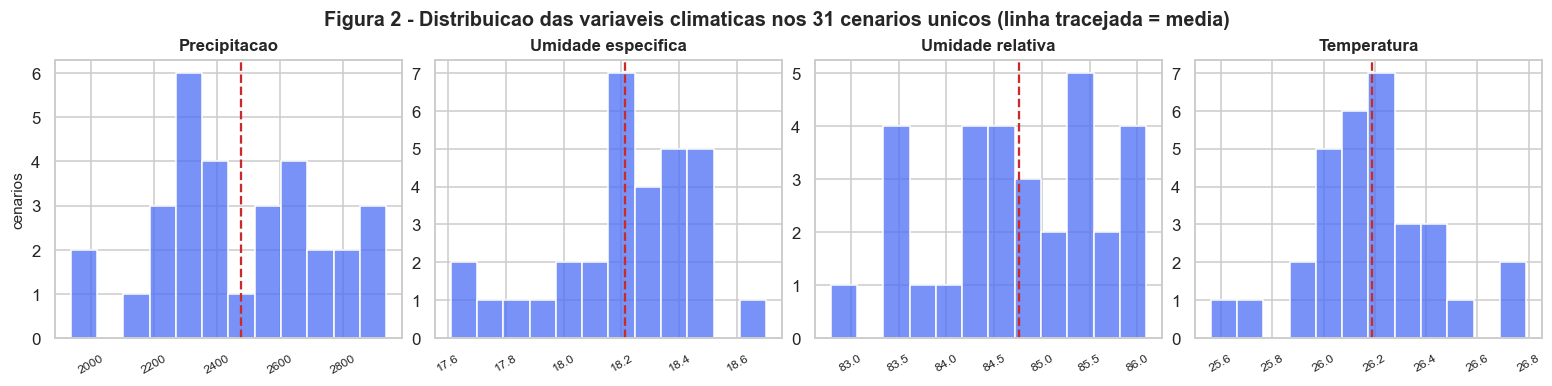

In [15]:
# Figura 2: distribuicao de cada variavel climatica entre os 31 cenarios unicos do desenvolvimento.
cenarios_dev = desenvolvimento.drop_duplicates("cenario")[["cenario"] + VAR_CLIMA].reset_index(drop=True)
print("Cenarios climaticos unicos no desenvolvimento:", len(cenarios_dev))

fig, eixos = plt.subplots(1, 4, figsize=(14, 3.4))
for eixo, variavel in zip(eixos, VAR_CLIMA):
    sns.histplot(cenarios_dev[variavel], bins=12, color="#4C6EF5", edgecolor="white", ax=eixo)
    eixo.axvline(cenarios_dev[variavel].mean(), color="#C92A2A", linestyle="--", linewidth=1.5)
    eixo.set_title(ROTULO_CLIMA[variavel], fontsize=11)
    eixo.set_xlabel("")
    eixo.set_ylabel("cenarios" if variavel == VAR_CLIMA[0] else "")
    eixo.tick_params(axis="x", labelrotation=30, labelsize=8)

fig.suptitle("Figura 2 - Distribuicao das variaveis climaticas nos 31 cenarios unicos "
             "(linha tracejada = media)", fontsize=13, fontweight="bold")
salvar_figura(fig, "fig02_distribuicao_clima")
plt.show()

> **Por que 31 cenários e não 124 linhas?** Cada condição climática se repete quatro vezes na base
> (uma por cultura). Se usássemos as 124 linhas, cada cenário entraria quatro vezes na conta —
> o histograma teria a mesma forma, mas qualquer contagem de observações ficaria quatro vezes
> inflada por repetição conhecida. Para descrever o *clima*, o registro correto é o cenário, não a
> linha.

## 5.4 Correlações — e por que a matriz global engana

figura salva: docs\figuras\fig03_correlacoes.png


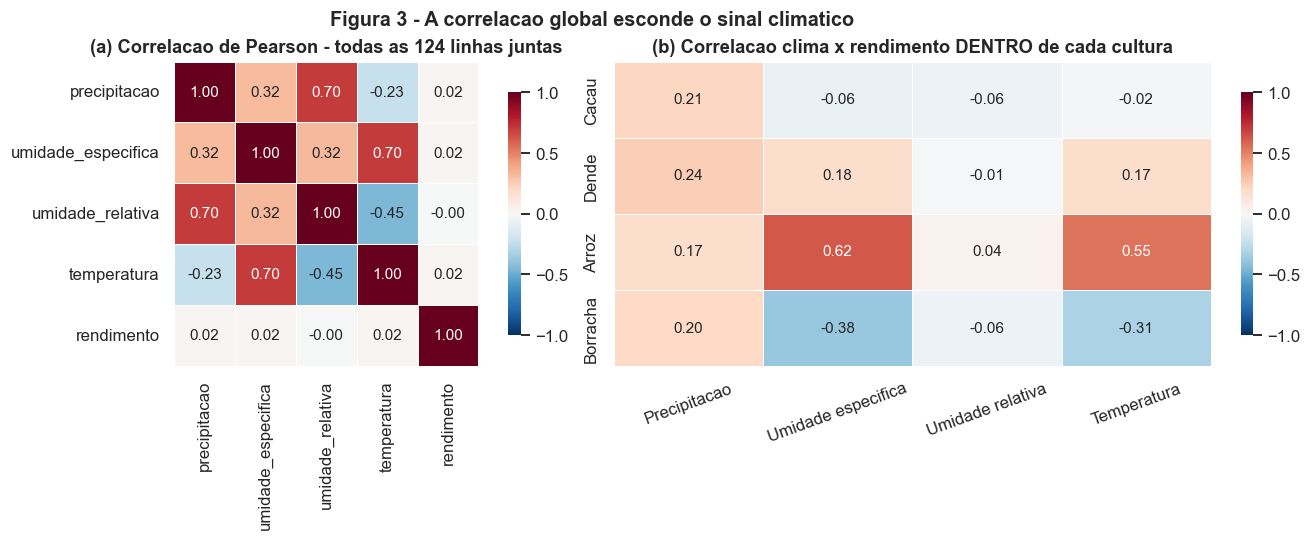

,Precipitacao,Umidade especifica,Umidade relativa,Temperatura
cultura,,,,
Cacau,0.211,-0.063,-0.056,-0.018
Dende,0.245,0.178,-0.012,0.173
Arroz,0.172,0.617,0.044,0.546
Borracha,0.202,-0.382,-0.055,-0.313


In [16]:
# Figura 3: correlacoes calculadas de duas formas diferentes.
fig, eixos = plt.subplots(1, 2, figsize=(13, 4.8))

# (a) matriz global, usando as 124 linhas do desenvolvimento
corr_global = desenvolvimento[VAR_CLIMA + [ALVO]].corr()
sns.heatmap(corr_global, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=eixos[0])
eixos[0].set_title("(a) Correlacao de Pearson - todas as 124 linhas juntas")

# (b) correlacao entre clima e rendimento DENTRO de cada cultura
linhas_corr = []
for cultura, grupo in desenvolvimento.groupby("cultura"):
    linhas_corr.append({ROTULO_CLIMA[v]: grupo[v].corr(grupo[ALVO]) for v in VAR_CLIMA} |
                       {"cultura": ROTULO_CURTO[cultura]})
corr_intra = pd.DataFrame(linhas_corr).set_index("cultura")
sns.heatmap(corr_intra, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=eixos[1])
eixos[1].set_title("(b) Correlacao clima x rendimento DENTRO de cada cultura")
eixos[1].set_ylabel("")
eixos[1].tick_params(axis="x", labelrotation=20)

fig.suptitle("Figura 3 - A correlacao global esconde o sinal climatico",
             fontsize=13, fontweight="bold")
salvar_figura(fig, "fig03_correlacoes")
plt.show()

display(corr_intra.round(3))

**Leitura da Figura 3.** O painel (a) mostra correlações praticamente nulas entre cada variável
climática e o rendimento (todas entre −0,02 e +0,04). Se parássemos aqui, concluiríamos que o clima
não tem relação nenhuma com a produtividade — e estaríamos errados.

O motivo é o **paradoxo de Simpson**: as quatro culturas ocupam faixas de rendimento completamente
diferentes e todas compartilham exatamente os mesmos 31 cenários climáticos. Ao empilhar tudo,
a variação entre culturas (que não tem relação com o clima, porque o clima é o mesmo para as
quatro) domina o cálculo e dilui qualquer efeito real.

O painel (b) calcula a correlação separadamente dentro de cada cultura, e o quadro muda:

| Cultura | Correlação linear com o rendimento, dentro da cultura |
| --- | --- |
| **Arroz** | Positiva e forte com umidade específica (**+0,70**) e temperatura (**+0,61**) |
| **Borracha** | **Negativa** e moderada com as mesmas duas variáveis (**−0,43** e **−0,41**) |
| **Cacau** | Todas fracas (abaixo de 0,18 em módulo) |
| **Dendê** | Todas fracas (abaixo de 0,23 em módulo) |

Ou seja: **as associações lineares entre clima e rendimento ficaram mais evidentes em arroz e
borracha nesta amostra**, e com sinais opostos entre as duas culturas.

**O que isso não permite afirmar:**

- Correlações fracas em cacau e dendê **não demonstram ausência de relação**. Com 31 cenários e uma
  faixa climática estreita, uma associação real, não linear ou de efeito pequeno passaria
  despercebida.
- A correlação de Pearson mede apenas associação **linear**.
- Nada disso é evidência causal: não há controle experimental nem informação de solo, manejo,
  adubação, variedade ou irrigação. Como a base não traz local, ano nem sistema de cultivo, também
  não é possível apoiar a leitura em características agronômicas específicas dessas culturas — o
  que se observa é a associação nos números, e só.

figura salva: docs\figuras\fig04_clima_vs_rendimento.png


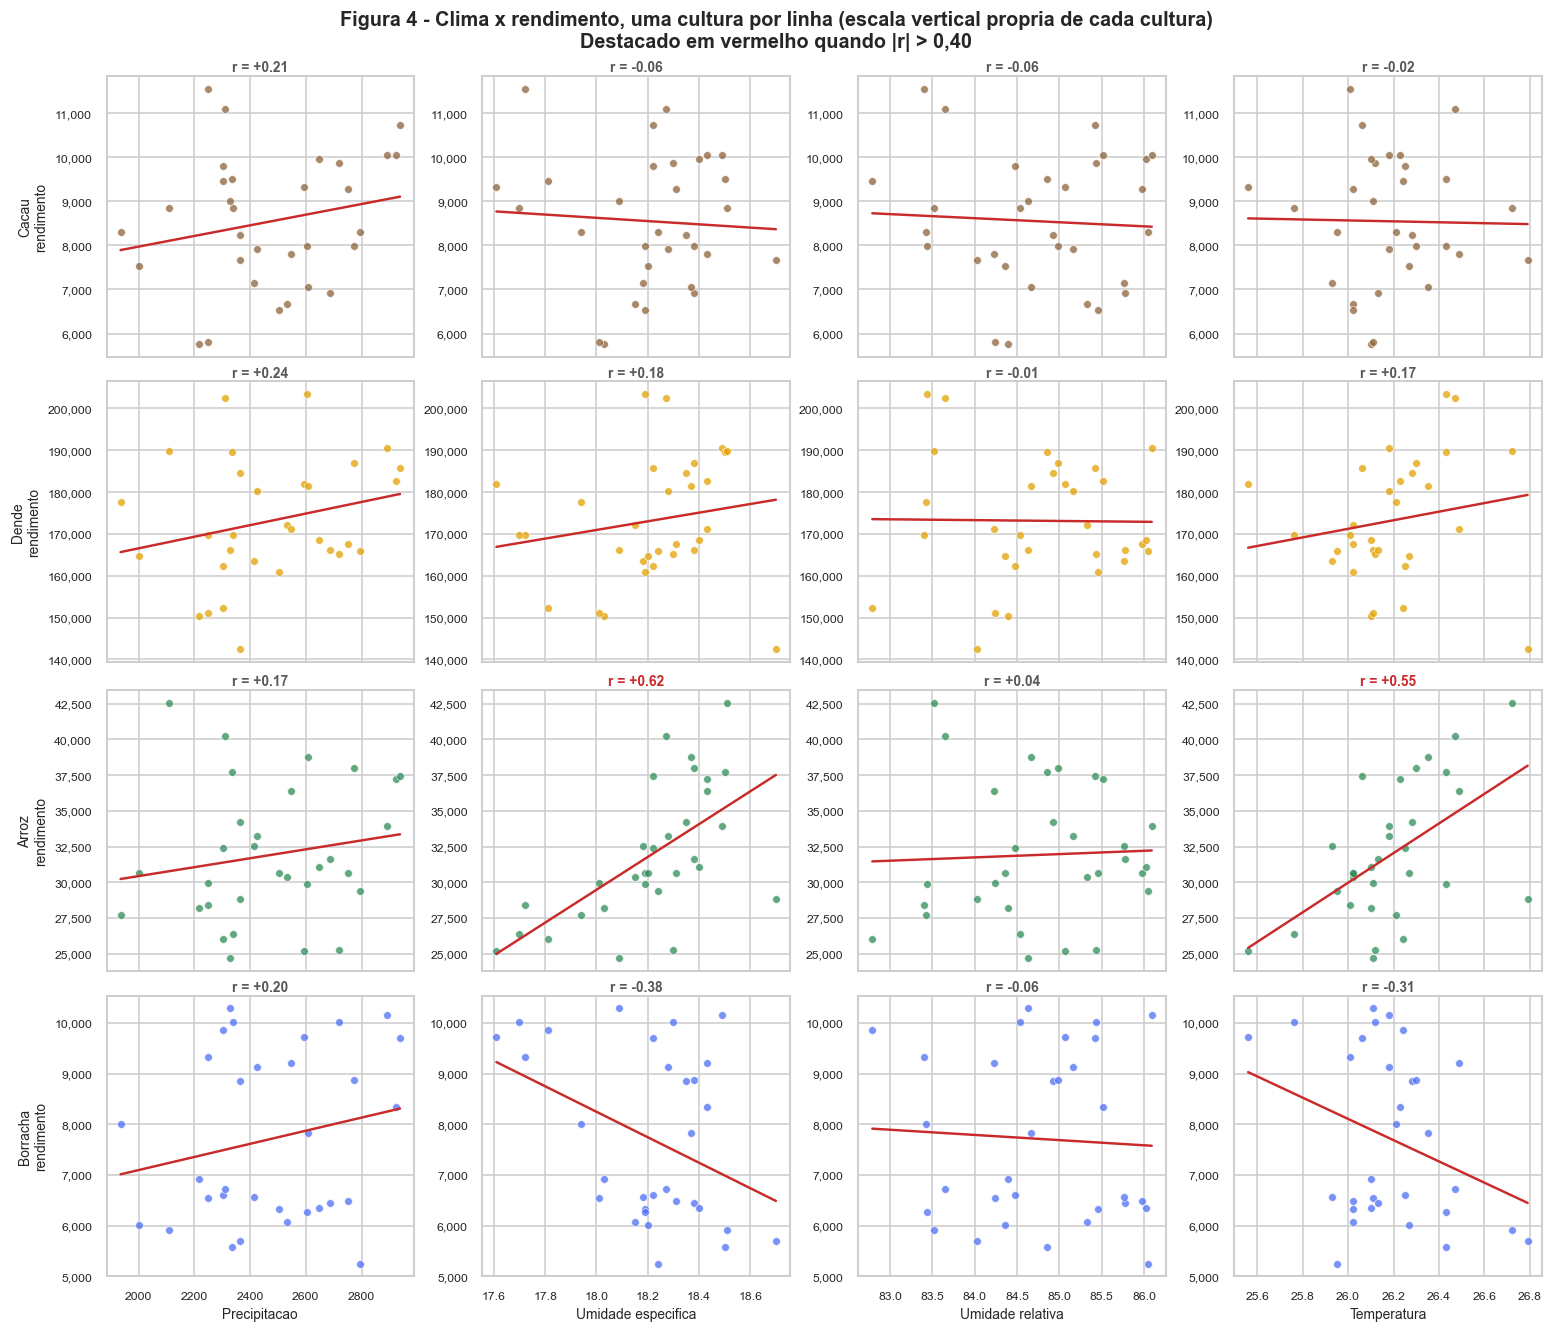

In [17]:
# Figura 4: dispersao clima x rendimento, com um painel por cultura e escala propria em cada linha.
fig, eixos = plt.subplots(4, 4, figsize=(14, 12), sharex="col")

for i, cultura in enumerate(ordem):
    sub = desenvolvimento[desenvolvimento["cultura"] == cultura]
    for j, variavel in enumerate(VAR_CLIMA):
        eixo = eixos[i, j]
        eixo.scatter(sub[variavel], sub[ALVO], s=26, alpha=0.75,
                     color=CORES_CULTURA[cultura], edgecolor="white", linewidth=0.5)
        # reta de tendencia simples, apenas como apoio visual
        coef = np.polyfit(sub[variavel], sub[ALVO], 1)
        grade = np.linspace(sub[variavel].min(), sub[variavel].max(), 50)
        eixo.plot(grade, np.polyval(coef, grade), color="#C92A2A", linewidth=1.6)
        r = sub[variavel].corr(sub[ALVO])
        eixo.set_title("r = {:+.2f}".format(r), fontsize=9,
                       color="#C92A2A" if abs(r) > 0.4 else "0.35", pad=3)
        eixo.tick_params(labelsize=8)
        eixo.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter("{x:,.0f}"))
        if j == 0:
            eixo.set_ylabel(ROTULO_CURTO[cultura] + "\nrendimento", fontsize=9)
        if i == 3:
            eixo.set_xlabel(ROTULO_CLIMA[variavel], fontsize=9)

fig.suptitle("Figura 4 - Clima x rendimento, uma cultura por linha (escala vertical propria de cada cultura)\n"
             "Destacado em vermelho quando |r| > 0,40", fontsize=13, fontweight="bold")
salvar_figura(fig, "fig04_clima_vs_rendimento")
plt.show()

**Leitura da Figura 4.** Cada linha usa a escala vertical da própria cultura, o que torna as
inclinações comparáveis. As únicas relações visualmente convincentes são as do arroz com umidade
específica e temperatura, e as da borracha com as mesmas duas variáveis, em sentido contrário.
Nas linhas do cacau e do dendê a nuvem de pontos é essencialmente horizontal.

## 5.5 Multicolinearidade: as quatro variáveis climáticas não são independentes

In [18]:
# Verificacao de multicolinearidade entre as quatro variaveis climaticas,
# usando os 31 cenarios unicos (nao as 124 linhas, para nao inflar artificialmente o n).
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# O escalonamento e ajustado sobre os cenarios do desenvolvimento e documentado como tal.
escalonador_cenarios = StandardScaler().fit(cenarios_dev[VAR_CLIMA])
X_cenarios = escalonador_cenarios.transform(cenarios_dev[VAR_CLIMA])

# Fator de inflacao de variancia (VIF): quanto cada variavel e explicada pelas outras tres.
linhas_vif = []
for i, variavel in enumerate(VAR_CLIMA):
    outras = [j for j in range(len(VAR_CLIMA)) if j != i]
    r2 = LinearRegression().fit(X_cenarios[:, outras], X_cenarios[:, i]).score(X_cenarios[:, outras], X_cenarios[:, i])
    linhas_vif.append({"variavel": variavel, "R2_pelas_outras": r2, "VIF": 1.0 / max(1e-12, 1.0 - r2)})
tabela_vif = pd.DataFrame(linhas_vif)
display(tabela_vif.round({"R2_pelas_outras": 4, "VIF": 1}))

# Analise de componentes principais: quantas dimensoes reais existem?
pca_clima = PCA().fit(X_cenarios)
tabela_pca = pd.DataFrame({
    "componente": ["CP1", "CP2", "CP3", "CP4"],
    "variancia_explicada_%": (pca_clima.explained_variance_ratio_ * 100),
    "acumulada_%": (pca_clima.explained_variance_ratio_.cumsum() * 100),
})
print("")
display(tabela_pca.round(3))

,variavel,R2_pelas_outras,VIF
0,precipitacao,0.4971,2.0
1,umidade_especifica,0.9990,991.9
2,umidade_relativa,0.9984,637.4
3,temperatura,0.9991,1115.1


,componente,variancia_explicada_%,acumulada_%
0,CP1,49.080,49.080
1,CP2,42.596,91.676
2,CP3,8.315,99.991
3,CP4,0.009,100.000


**Leitura.** Umidade específica, umidade relativa e temperatura têm **VIF acima de 600** — cada uma
delas é reconstruída com R² por volta de 0,999 a partir das outras duas. Isso é compatível com a
relação psicrométrica que liga essas três grandezas (a umidade específica é aproximadamente uma
função da umidade relativa e da temperatura). A quarta componente principal responde por **0,009%**
da variância: um valor muito pequeno, mas **não exatamente zero**.

**Consequências práticas:**

1. A variação climática se concentra em **cerca de três dimensões**, e as duas primeiras componentes
   já somam 91,7% — o que justifica usar duas componentes para visualizar os grupos na seção 6.
2. Os **coeficientes da regressão linear não devem ser interpretados individualmente**. Com VIF nessa
   ordem, eles ficam numericamente instáveis e podem trocar de sinal com pequenas mudanças na
   amostra. Ninguém deve ler "o coeficiente da temperatura é X, logo cada grau adicional causa Y" a
   partir deste modelo.
3. A multicolinearidade afeta sobretudo a **estabilidade** dos coeficientes, mas com uma amostra
   pequena essa instabilidade também pode se refletir nas previsões. Não se pode afirmar que a
   qualidade preditiva fique imune.
4. Para a frente ML: se for necessário interpretar coeficientes, o caminho é uma regressão
   regularizada (Ridge) ou trabalhar sobre as componentes principais, não sobre as variáveis
   originais.

---
# 6. Clusterização: existem regimes climáticos distintos?

## 6.1 Duas decisões tomadas antes de rodar o algoritmo

**Decisão 1 — agrupar cenários, não linhas.** Se aplicássemos o K-Means às 124 linhas, cada
condição climática entraria quatro vezes no cálculo dos centroides. Como as quatro cópias são
idênticas nas variáveis usadas, isso não mudaria a forma dos grupos, mas faria o algoritmo (e a
silhueta) trabalhar com 124 pontos quando existem apenas 31 cenários climáticos distintos.
Agrupamos, portanto, os **31 cenários únicos do desenvolvimento**.

**Decisão 2 — não incluir o rendimento entre as variáveis do agrupamento.** Duas razões:

1. *Metodológica:* o rendimento é o alvo. Um agrupamento que o utiliza não pode virar entrada de um
   modelo preditivo, porque na hora de prever o rendimento é justamente ele que não se conhece.
2. *Prática:* como o dendê rende cerca de vinte vezes mais que o cacau, qualquer agrupamento que
   inclua o rendimento vai separar **culturas por escala**, não regimes climáticos. Demonstramos
   isso explicitamente na seção 6.5.

O escalonamento (`StandardScaler`) é obrigatório aqui: a precipitação varia em milhares de unidades
e a temperatura em décimos de grau. Sem padronizar, a distância euclidiana seria decidida
inteiramente pela precipitação. O escalonador é ajustado **sobre os 31 cenários do desenvolvimento**
— esta é uma análise descritiva independente, e o conjunto usado está declarado.

## 6.2 Escolha do número de grupos

Não presumimos que o número de grupos deva ser quatro só porque existem quatro culturas: as
culturas compartilham exatamente os mesmos cenários climáticos, então o número de regimes de clima
não tem relação alguma com o número de culturas. Avaliamos k de 2 a 8 com três critérios.

In [19]:
# ============================================================
# 6. CLUSTERIZACAO DOS CENARIOS CLIMATICOS
# ============================================================
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

# X_cenarios ja foi padronizado na secao 5.5 a partir dos 31 cenarios do desenvolvimento.
print("Matriz de agrupamento:", X_cenarios.shape, "(31 cenarios x 4 variaveis climaticas padronizadas)")

FAIXA_K = range(2, 9)
gerador = np.random.default_rng(SEED)   # gerador dedicado ao teste de estabilidade
avaliacao_k = []

for k in FAIXA_K:
    modelo_k = KMeans(n_clusters=k, random_state=SEED, n_init=20).fit(X_cenarios)
    rotulos_base = modelo_k.labels_

    # Estabilidade: reagrupa 50 subamostras de 80% e mede a concordancia com o agrupamento completo.
    # Um k util deve produzir aproximadamente os mesmos grupos quando parte dos dados e retirada.
    concordancias = []
    for _ in range(50):
        sorteio = gerador.choice(len(X_cenarios), int(0.8 * len(X_cenarios)), replace=False)
        rotulos_sub = KMeans(n_clusters=k, random_state=SEED, n_init=20).fit_predict(X_cenarios[sorteio])
        concordancias.append(adjusted_rand_score(rotulos_base[sorteio], rotulos_sub))

    # Ward como metodo alternativo, para conferir se a estrutura nao e um artefato do K-Means.
    rotulos_ward = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X_cenarios)

    avaliacao_k.append({
        "k": k,
        "inercia": modelo_k.inertia_,
        "silhueta_kmeans": silhouette_score(X_cenarios, rotulos_base),
        "silhueta_ward": silhouette_score(X_cenarios, rotulos_ward),
        "estabilidade_ARI": float(np.mean(concordancias)),
        "menor_grupo": int(np.bincount(rotulos_base).min()),
        "tamanhos": np.bincount(rotulos_base).tolist(),
    })

tabela_k = pd.DataFrame(avaliacao_k)
display(tabela_k.round({"inercia": 2, "silhueta_kmeans": 3, "silhueta_ward": 3, "estabilidade_ARI": 3}))

Matriz de agrupamento: (31, 4) (31 cenarios x 4 variaveis climaticas padronizadas)


,k,inercia,silhueta_kmeans,silhueta_ward,estabilidade_ARI,menor_grupo,tamanhos
0,2,77.62,0.325,0.324,0.725,15,"[15, 16]"
1,3,48.60,0.368,0.339,0.923,8,"[10, 8, 13]"
2,4,36.73,0.392,0.360,0.820,2,"[13, 8, 2, 8]"
3,5,29.52,0.316,0.347,0.654,2,"[6, 9, 8, 6, 2]"
4,6,24.20,0.313,0.305,0.650,2,"[5, 5, 2, 9, 8, 2]"
5,7,19.36,0.331,0.311,0.819,2,"[9, 6, 6, 4, 2, 2, 2]"
6,8,16.48,0.332,0.318,0.758,2,"[8, 6, 5, 2, 2, 2, 4, 2]"


figura salva: docs\figuras\fig05_escolha_k.png


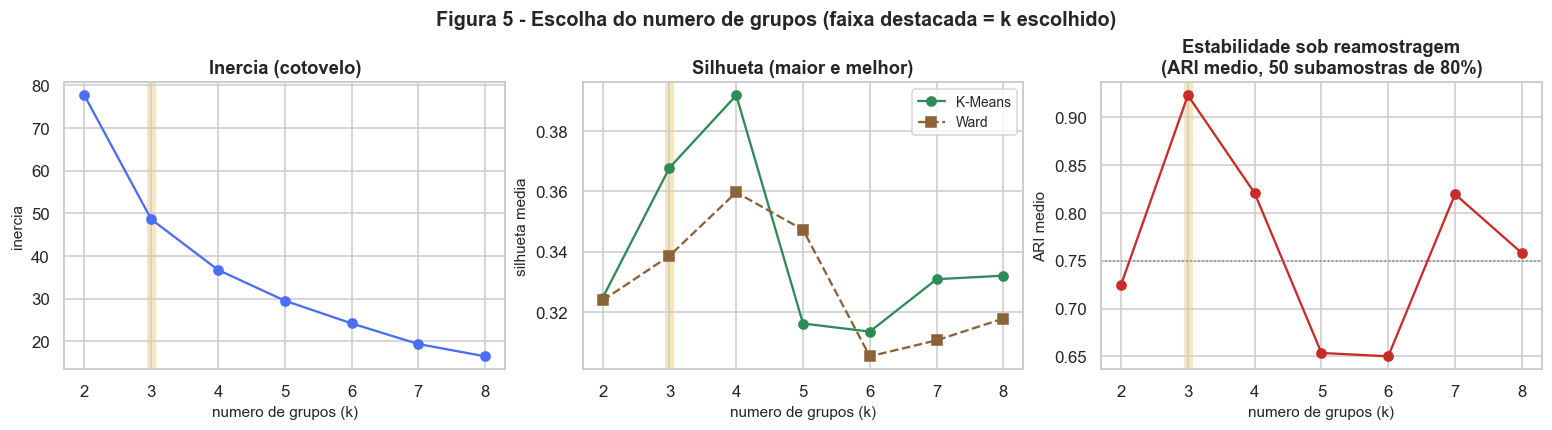

In [20]:
# Figura 5: os tres criterios de escolha de k lado a lado.
fig, eixos = plt.subplots(1, 3, figsize=(14, 3.8))

eixos[0].plot(tabela_k["k"], tabela_k["inercia"], marker="o", color="#4C6EF5")
eixos[0].set_title("Inercia (cotovelo)")
eixos[0].set_xlabel("numero de grupos (k)")
eixos[0].set_ylabel("inercia")

eixos[1].plot(tabela_k["k"], tabela_k["silhueta_kmeans"], marker="o", color="#2E8B57", label="K-Means")
eixos[1].plot(tabela_k["k"], tabela_k["silhueta_ward"], marker="s", linestyle="--", color="#8C6239", label="Ward")
eixos[1].set_title("Silhueta (maior e melhor)")
eixos[1].set_xlabel("numero de grupos (k)")
eixos[1].set_ylabel("silhueta media")
eixos[1].legend()

eixos[2].plot(tabela_k["k"], tabela_k["estabilidade_ARI"], marker="o", color="#C92A2A")
eixos[2].axhline(0.75, color="0.5", linestyle=":", linewidth=1)
eixos[2].set_title("Estabilidade sob reamostragem\n(ARI medio, 50 subamostras de 80%)")
eixos[2].set_xlabel("numero de grupos (k)")
eixos[2].set_ylabel("ARI medio")

for eixo in eixos:
    eixo.axvline(3, color="#E1A100", linewidth=6, alpha=0.25, zorder=0)   # destaque do k escolhido

fig.suptitle("Figura 5 - Escolha do numero de grupos (faixa destacada = k escolhido)",
             fontsize=13, fontweight="bold")
salvar_figura(fig, "fig05_escolha_k")
plt.show()

### Por que k = 3

Os valores obtidos, transcritos da tabela acima:

| k | Silhueta (K-Means) | Estabilidade (ARI) | Menor grupo | Observação |
| --- | --- | --- | --- | --- |
| 2 | 0,325 | 0,725 | 15 | Menor silhueta; estabilidade intermediária |
| **3** | **0,368** | **0,923** | **8** | **Escolhido:** maior estabilidade medida, grupos equilibrados |
| 4 | **0,392** | 0,820 | 2 | Maior silhueta, mas um dos grupos tem 2 cenários |
| 5 | 0,316 | 0,654 | 2 | Silhueta e estabilidade mais baixas |
| 6 | 0,313 | 0,650 | 2 | Silhueta e estabilidade mais baixas |
| 7 | 0,331 | **0,819** | 2 | Estabilidade volta a subir, com sete grupos e vários pares |
| 8 | 0,332 | 0,758 | 2 | Idem |

**A estabilidade não cai de forma monotônica com k.** Ela tem mínimo em k = 5 e 6 (cerca de 0,65) e
volta a subir em k = 7 (0,819) e k = 8 (0,758). O que sustenta a escolha, portanto, não é uma queda
geral dos demais valores, e sim que **k = 3 apresenta a maior estabilidade medida nesta execução
(0,923)**, com grupos de tamanho equilibrado (10, 8 e 13 cenários).

**Sobre o k = 4**, que tem a maior silhueta (0,392 contra 0,368): o quarto grupo é formado por
**apenas dois cenários**, os dois mais frios do conjunto, que a seção 7 também assinala entre os
extremos climáticos. Um grupo tão pequeno **pode** corresponder a um regime real — não há como
descartar isso com 31 cenários —, mas é frágil como base de interpretação, porque qualquer
conclusão sobre ele se apoiaria em duas observações. Somado à estabilidade menor (0,820 contra
0,923), isso motiva preferir a solução de três grupos **nesta amostra**, sem afirmar que k = 4
esteja errado.

O método aglomerativo de Ward produz um ordenamento qualitativo semelhante, o que sugere que a
estrutura não é um artefato do K-Means.

**Em linguagem simples:** dividir os 31 cenários em três regimes é a partição que mais se repete
quando retiramos ao acaso 20% dos cenários e refazemos a conta. É essa reprodutibilidade, e não o
valor absoluto da silhueta, que orienta a escolha.

In [21]:
# Agrupamento final com k=3.
K_ESCOLHIDO = 3
modelo_agrupamento = KMeans(n_clusters=K_ESCOLHIDO, random_state=SEED, n_init=20).fit(X_cenarios)
cenarios_dev["grupo_num"] = modelo_agrupamento.labels_

# Nomes descritivos atribuidos por regra objetiva sobre o perfil medio de cada grupo,
# para que os rotulos nao dependam da ordem interna do algoritmo.
perfil_bruto = cenarios_dev.groupby("grupo_num")[VAR_CLIMA].mean()
id_chuvoso = perfil_bruto["precipitacao"].idxmax()                      # maior precipitacao
restantes = [g for g in perfil_bruto.index if g != id_chuvoso]
id_quente = perfil_bruto.loc[restantes, "temperatura"].idxmax()         # entre os demais, o mais quente
id_ameno = [g for g in restantes if g != id_quente][0]

NOMES_GRUPO = {id_chuvoso: "Chuvoso", id_quente: "Quente e abafado", id_ameno: "Ameno e seco"}
ORDEM_GRUPOS = ["Ameno e seco", "Chuvoso", "Quente e abafado"]
CORES_GRUPO = {"Ameno e seco": "#4C6EF5", "Chuvoso": "#2E8B57", "Quente e abafado": "#C92A2A"}

cenarios_dev["grupo"] = cenarios_dev["grupo_num"].map(NOMES_GRUPO)

# Perfil de cada grupo em unidades originais e em desvios-padrao em relacao a media geral.
perfil = cenarios_dev.groupby("grupo")[VAR_CLIMA].mean().reindex(ORDEM_GRUPOS)
perfil.insert(0, "n_cenarios", cenarios_dev["grupo"].value_counts().reindex(ORDEM_GRUPOS))
print("=== Perfil medio de cada grupo (unidades originais) ===")
display(perfil.round(2))

perfil_padronizado = pd.DataFrame(
    escalonador_cenarios.transform(perfil[VAR_CLIMA]), index=perfil.index, columns=VAR_CLIMA
)
print("=== Mesmo perfil em desvios-padrao em relacao a media dos 31 cenarios ===")
display(perfil_padronizado.round(2))

=== Perfil medio de cada grupo (unidades originais) ===


,n_cenarios,precipitacao,umidade_especifica,umidade_relativa,temperatura
grupo,,,,,
Ameno e seco,8,2276.20,17.86,84.06,26.01
Chuvoso,13,2691.90,18.30,85.61,26.10
Quente e abafado,10,2353.91,18.37,84.22,26.45


=== Mesmo perfil em desvios-padrao em relacao a media dos 31 cenarios ===


,precipitacao,umidade_especifica,umidade_relativa,temperatura
grupo,,,,
Ameno e seco,-0.78,-1.40,-0.78,-0.71
Chuvoso,0.84,0.36,0.95,-0.38
Quente e abafado,-0.47,0.64,-0.61,1.06


figura salva: docs\figuras\fig06_clusters.png


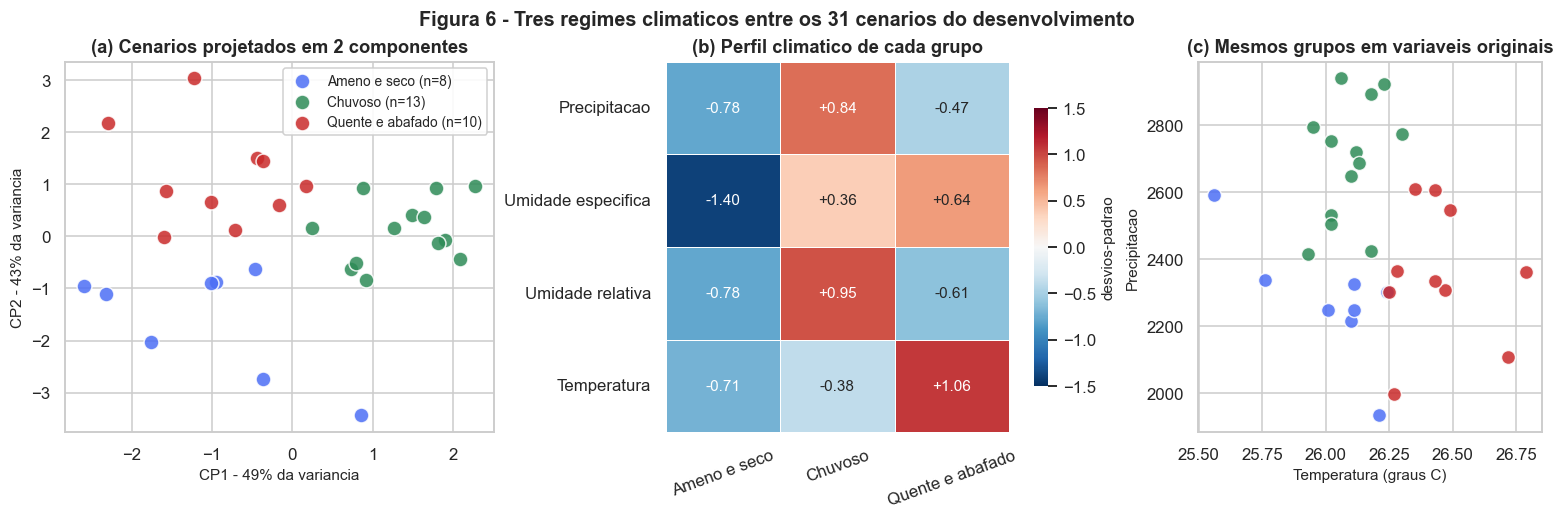

In [22]:
# Figura 6: visao geral do agrupamento.
fig = plt.figure(figsize=(14, 4.6))
grade = fig.add_gridspec(1, 3, width_ratios=[1.25, 1.0, 1.0])

# (a) projecao em duas componentes principais (91,7% da variancia)
pontos_pca = PCA(n_components=2, random_state=SEED).fit_transform(X_cenarios)
eixo_a = fig.add_subplot(grade[0])
for nome in ORDEM_GRUPOS:
    marca = cenarios_dev["grupo"] == nome
    eixo_a.scatter(pontos_pca[marca.values, 0], pontos_pca[marca.values, 1], s=95, alpha=0.85,
                   color=CORES_GRUPO[nome], edgecolor="white", linewidth=1,
                   label=nome + " (n=" + str(int(marca.sum())) + ")")
eixo_a.set_xlabel("CP1 - {:.0f}% da variancia".format(pca_clima.explained_variance_ratio_[0] * 100))
eixo_a.set_ylabel("CP2 - {:.0f}% da variancia".format(pca_clima.explained_variance_ratio_[1] * 100))
eixo_a.set_title("(a) Cenarios projetados em 2 componentes")
eixo_a.legend(loc="best", framealpha=0.9)

# (b) perfil padronizado de cada grupo
eixo_b = fig.add_subplot(grade[1])
sns.heatmap(perfil_padronizado.T, annot=True, fmt="+.2f", cmap="RdBu_r", center=0,
            vmin=-1.5, vmax=1.5, linewidths=0.5, cbar_kws={"shrink": 0.75, "label": "desvios-padrao"},
            ax=eixo_b, yticklabels=[ROTULO_CLIMA[v] for v in VAR_CLIMA])
eixo_b.set_title("(b) Perfil climatico de cada grupo")
eixo_b.set_xlabel("")
eixo_b.tick_params(axis="x", labelrotation=20)

# (c) precipitacao x temperatura, as duas variaveis mais interpretaveis
eixo_c = fig.add_subplot(grade[2])
for nome in ORDEM_GRUPOS:
    sub = cenarios_dev[cenarios_dev["grupo"] == nome]
    eixo_c.scatter(sub["temperatura"], sub["precipitacao"], s=85, alpha=0.85,
                   color=CORES_GRUPO[nome], edgecolor="white", linewidth=1, label=nome)
eixo_c.set_xlabel("Temperatura (graus C)")
eixo_c.set_ylabel("Precipitacao")
eixo_c.set_title("(c) Mesmos grupos em variaveis originais")

fig.suptitle("Figura 6 - Tres regimes climaticos entre os 31 cenarios do desenvolvimento",
             fontsize=13, fontweight="bold")
salvar_figura(fig, "fig06_clusters")
plt.show()

### 6.3 O que cada grupo representa

| Grupo | Cenários | Perfil climático |
| --- | --- | --- |
| **Chuvoso** | 13 | Maior precipitação e maior umidade relativa; temperatura intermediária |
| **Quente e abafado** | 10 | Maior temperatura e maior umidade específica; precipitação abaixo da média |
| **Ameno e seco** | 8 | Menor temperatura e menor umidade específica; precipitação mais baixa |

Note que a separação segue **os dois eixos de maior variância**, exatamente os dois que a análise de
componentes principais identificou na seção 5.5: um eixo de água (precipitação e umidade relativa)
e um eixo de calor (temperatura e umidade específica, ligadas pela relação psicrométrica).

## 6.4 Os grupos climáticos se relacionam com o rendimento?

In [23]:
# Junta o rotulo de grupo de volta as linhas do desenvolvimento (pelo identificador de cenario).
dev_agrupado = desenvolvimento.merge(cenarios_dev[["cenario", "grupo"]], on="cenario", how="left")

# Rendimento medio por cultura e grupo, e desvio percentual em relacao a media da propria cultura.
media_por_cultura_grupo = dev_agrupado.pivot_table(index="cultura", columns="grupo",
                                                   values=ALVO, aggfunc="mean").reindex(columns=ORDEM_GRUPOS)
media_da_cultura = dev_agrupado.groupby("cultura")[ALVO].mean()
desvio_percentual = (media_por_cultura_grupo.div(media_da_cultura, axis=0) - 1) * 100

print("=== Rendimento medio por cultura e grupo climatico (un. do arquivo) ===")
display(media_por_cultura_grupo.round(0))
print("=== Desvio percentual em relacao a media da propria cultura ===")
display(desvio_percentual.round(1))

# Numero de linhas em cada celula, para deixar claro o tamanho das amostras.
print("=== Numero de observacoes por celula ===")
display(dev_agrupado.pivot_table(index="cultura", columns="grupo", values=ALVO,
                                 aggfunc="size").reindex(columns=ORDEM_GRUPOS))

=== Rendimento medio por cultura e grupo climatico (un. do arquivo) ===


grupo,Ameno e seco,Chuvoso,Quente e abafado
cultura,,,
"Cocoa, beans",8508.0,8570.0,8552.0
Oil palm fruit,164852.0,173576.0,179208.0
"Rice, paddy",27064.0,32408.0,35157.0
"Rubber, natural",8834.0,7670.0,6865.0


=== Desvio percentual em relacao a media da propria cultura ===


grupo,Ameno e seco,Chuvoso,Quente e abafado
cultura,,,
"Cocoa, beans",-0.5,0.3,0.0
Oil palm fruit,-4.8,0.3,3.5
"Rice, paddy",-15.2,1.5,10.2
"Rubber, natural",14.6,-0.5,-11.0


=== Numero de observacoes por celula ===


grupo,Ameno e seco,Chuvoso,Quente e abafado
cultura,,,
"Cocoa, beans",8,13,10
Oil palm fruit,8,13,10
"Rice, paddy",8,13,10
"Rubber, natural",8,13,10


figura salva: docs\figuras\fig07_grupos_vs_rendimento.png


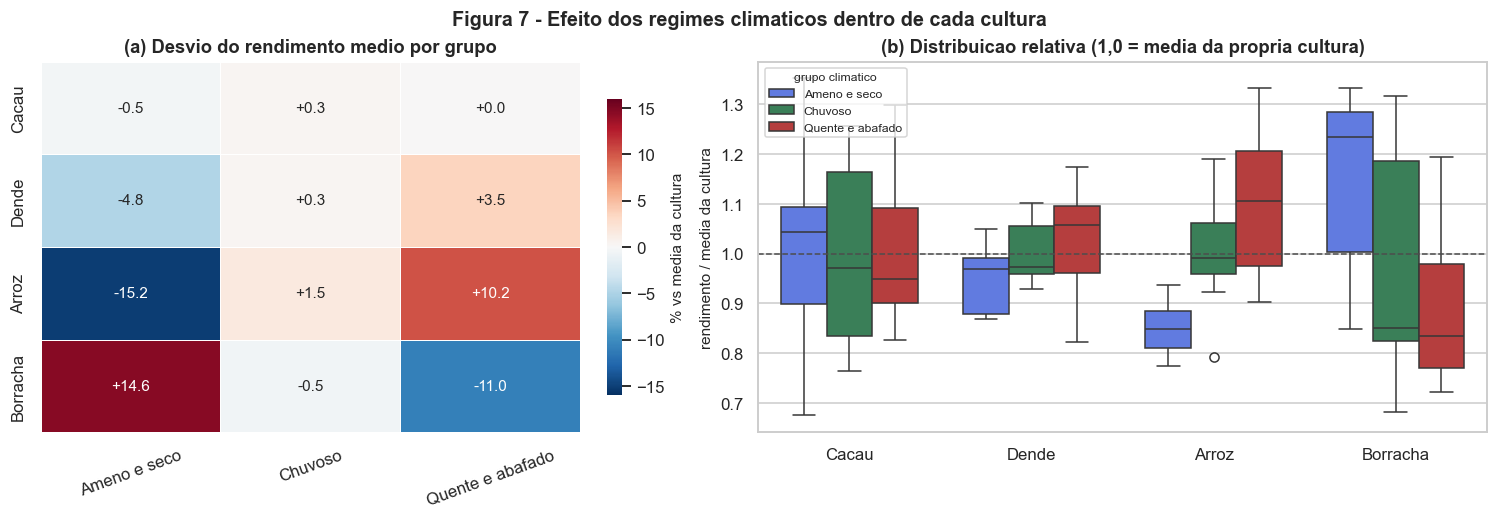

In [24]:
# Figura 7: o desvio percentual e a distribuicao por tras dele.
fig, eixos = plt.subplots(1, 2, figsize=(13.5, 4.6), gridspec_kw={"width_ratios": [1, 1.35]})

# (a) mapa de calor do desvio percentual
mapa = desvio_percentual.rename(index=ROTULO_CURTO)
sns.heatmap(mapa, annot=True, fmt="+.1f", cmap="RdBu_r", center=0, vmin=-16, vmax=16,
            linewidths=0.6, cbar_kws={"shrink": 0.8, "label": "% vs media da cultura"}, ax=eixos[0])
eixos[0].set_title("(a) Desvio do rendimento medio por grupo")
eixos[0].set_xlabel("")
eixos[0].set_ylabel("")
eixos[0].tick_params(axis="x", labelrotation=20)

# (b) distribuicao do rendimento normalizado pela media da cultura
dev_agrupado["rendimento_relativo"] = dev_agrupado[ALVO] / dev_agrupado["cultura"].map(media_da_cultura)
sns.boxplot(data=dev_agrupado, x="cultura", y="rendimento_relativo", hue="grupo",
            order=ordem, hue_order=ORDEM_GRUPOS,
            palette=[CORES_GRUPO[g] for g in ORDEM_GRUPOS], width=0.75, ax=eixos[1])
eixos[1].axhline(1.0, color="0.3", linestyle="--", linewidth=1)
eixos[1].set_xticks(range(len(ordem)))
eixos[1].set_xticklabels([ROTULO_CURTO[c] for c in ordem])
eixos[1].set_xlabel("")
eixos[1].set_ylabel("rendimento / media da cultura")
eixos[1].set_title("(b) Distribuicao relativa (1,0 = media da propria cultura)")
eixos[1].legend(title="grupo climatico", loc="upper left", fontsize=8, title_fontsize=8)

fig.suptitle("Figura 7 - Efeito dos regimes climaticos dentro de cada cultura",
             fontsize=13, fontweight="bold")
salvar_figura(fig, "fig07_grupos_vs_rendimento")
plt.show()

### Interpretação — e seus limites

O padrão mais visível é um **contraste entre arroz e borracha**:

- No regime **Quente e abafado**, a média do arroz fica **+10,2%** acima da média da própria cultura,
  enquanto a da borracha fica **−11,0%** abaixo.
- No regime **Ameno e seco**, a relação se inverte: arroz **−15,2%**, borracha **+14,6%**.
- O regime **Chuvoso** fica próximo da média em todas as culturas (entre −0,5% e +1,5%).
- Em **cacau e dendê** as diferenças entre grupos são muito menores: no máximo 0,5% e 4,8%,
  respectivamente.

Isso é **coerente com o que as correlações da seção 5.4 indicavam** — mas trata-se de outra leitura
dos **mesmos dados**, com o mesmo agrupamento de linhas, e não de uma confirmação independente. As
duas análises compartilham as mesmas 124 observações e as mesmas limitações.

**Limitações que precisam acompanhar essa leitura:**

1. **Amostras pequenas.** Cada célula da tabela tem entre 8 e 13 observações. Uma diferença de 10%
   com 8 observações não é um resultado estatisticamente estabelecido, e nenhum teste de
   significância foi aplicado aqui.
2. **Diferenças pequenas não são ausência de efeito.** Cacau e dendê variaram pouco entre os grupos
   *nesta amostra*; isso não demonstra que sejam insensíveis ao clima.
3. **Sem evidência causal.** Não há informação sobre solo, variedade, adubação, manejo, irrigação ou
   controle de pragas. O regime climático pode estar servindo de indicador indireto de outros
   fatores não observados.
4. **Faixa climática estreita.** Todos os cenários ficam entre 25,6 e 26,8 °C. Nada aqui autoriza
   extrapolar para climas fora dessa faixa.
5. **Sem estrutura temporal ou geográfica.** A base não tem data nem local. Não é possível separar
   efeito climático de tendência tecnológica, de variação de área plantada ou de qualquer fator que
   mude ao longo do tempo ou entre regiões.

## 6.5 Contraexemplo: o que acontece se o rendimento entrar no agrupamento

In [25]:
# Demonstracao do erro que a secao 6.1 justificou evitar.
X_com_rendimento = StandardScaler().fit_transform(desenvolvimento[VAR_CLIMA + [ALVO]])
grupos_errados = KMeans(n_clusters=4, random_state=SEED, n_init=20).fit_predict(X_com_rendimento)

cruzamento = pd.crosstab(desenvolvimento["cultura"].map(ROTULO_CURTO), grupos_errados)
cruzamento.columns = ["grupo " + str(c) for c in cruzamento.columns]
print("=== K-Means com k=4 INCLUINDO o rendimento (124 linhas) ===")
display(cruzamento)

# O que esses quatro grupos realmente sao? Tres verificacoes.
# (a) existe um grupo praticamente exclusivo do dende, a cultura de maior escala?
composicao = cruzamento.div(cruzamento.sum(axis=0), axis=1) * 100
grupo_do_dende = composicao.loc["Dende"].idxmax()
print("(a)", grupo_do_dende, "e composto por {:.0f}% de dende".format(composicao.loc["Dende", grupo_do_dende]),
      "e concentra", int(cruzamento.loc["Dende", grupo_do_dende]), "das",
      int(cruzamento.loc["Dende"].sum()), "linhas dessa cultura.")

# (b) as tres culturas de menor rendimento ficam distribuidas de forma identica?
tres_menores = cruzamento.drop(index="Dende")
print("(b) Cacau, Arroz e Borracha tem distribuicao identica entre os grupos:",
      bool(tres_menores.nunique(axis=0).eq(1).all()), "->", tres_menores.iloc[0].tolist())

# (c) essa distribuicao coincide com os tres regimes climaticos ja encontrados na secao 6.3?
sem_dende = (desenvolvimento["cultura"] != "Oil palm fruit").to_numpy()
concordancia_clima = adjusted_rand_score(dev_agrupado.loc[sem_dende, "grupo"], grupos_errados[sem_dende])
print("(c) Concordancia com os 3 regimes climaticos da secao 6.3, excluindo o dende (ARI): {:.3f}".format(
    concordancia_clima), "-> 1,000 significa particao exatamente igual.")

=== K-Means com k=4 INCLUINDO o rendimento (124 linhas) ===


,grupo 0,grupo 1,grupo 2,grupo 3
cultura,,,,
Arroz,10,13,8,0
Borracha,10,13,8,0
Cacau,10,13,8,0
Dende,2,0,7,22


(a) grupo 3 e composto por 100% de dende e concentra 22 das 31 linhas dessa cultura.
(b) Cacau, Arroz e Borracha tem distribuicao identica entre os grupos: True -> [10, 13, 8, 0]
(c) Concordancia com os 3 regimes climaticos da secao 6.3, excluindo o dende (ARI): 1.000 -> 1,000 significa particao exatamente igual.


**Leitura — o agrupamento com rendimento não descobre nada de novo.** As três verificações mostram
exatamente do que ele é feito:

- **(a)** Um dos quatro grupos é **100% dendê** e concentra 22 das 31 linhas dessa cultura. Ele não é
  um regime climático: é a cultura de maior escala, isolada pela sua própria magnitude.
- **(b)** Cacau, arroz e borracha se distribuem de forma **exatamente idêntica** (10, 13 e 8 linhas)
  pelos três grupos restantes — porque compartilham os mesmos cenários climáticos e, na escala
  padronizada, os seus rendimentos são todos pequenos perto do dendê.
- **(c)** E esses três grupos restantes são, com **ARI = 1,000**, a **mesma partição** que já
  tínhamos encontrado usando só o clima. Note que 10, 13 e 8 são precisamente os tamanhos dos grupos
  "Quente e abafado", "Chuvoso" e "Ameno e seco" da seção 6.3.

Ou seja: incluir o rendimento não acrescentou informação nenhuma — apenas gastou um dos quatro
grupos para dizer "isto aqui é dendê", algo que a coluna `Crop` já informava de graça. Se
apresentássemos o resultado como "descobrimos quatro perfis de produtividade", estaríamos vendendo
como descoberta um rótulo que já estava na base.

**É por isso que o rendimento fica fora do agrupamento**, e é por isso que a seção 6.4 mede o efeito
climático como desvio percentual *dentro* de cada cultura, e não em valor absoluto.

---
# 7. Investigação de outliers

Separamos a investigação em duas perguntas distintas, porque elas têm respostas diferentes:

1. **Existem condições climáticas atípicas** entre os 31 cenários?
2. **Existem rendimentos atípicos** dentro de cada cultura?

Nenhuma observação é removida neste notebook. O objetivo é entender o que os pontos extremos
representam e registrar o efeito que teriam sobre os modelos.

## 7.1 Cenários climáticos atípicos

In [26]:
# ============================================================
# 7. OUTLIERS
# ============================================================
from sklearn.ensemble import IsolationForest

# Criterio 1 - regra do IQR aplicada a cada variavel climatica isoladamente.
diagnostico = cenarios_dev.copy()
limites = []
for variavel in VAR_CLIMA:
    q1, q3 = diagnostico[variavel].quantile([0.25, 0.75])
    intervalo = q3 - q1
    inferior, superior = q1 - 1.5 * intervalo, q3 + 1.5 * intervalo
    diagnostico["fora_" + variavel] = (diagnostico[variavel] < inferior) | (diagnostico[variavel] > superior)
    limites.append({"variavel": variavel, "limite_inferior": inferior, "limite_superior": superior,
                    "n_fora": int(diagnostico["fora_" + variavel].sum())})
display(pd.DataFrame(limites).round(2))

diagnostico["marcas_iqr"] = diagnostico[["fora_" + v for v in VAR_CLIMA]].sum(axis=1)

# Criterio 2 - IsolationForest, que avalia a combinacao das quatro variaveis ao mesmo tempo.
# Observacao: a distancia de Mahalanobis seria a escolha classica, mas a matriz de covariancia
# e quase singular aqui (VIF > 600, secao 5.5), o que a tornaria numericamente instavel.
#
# ATENCAO ao parametro contamination=0.10: ele NAO estima quantos atipicos existem, ele DEFINE
# que 10% dos cenarios serao marcados. Com 31 cenarios, isso equivale a marcar 3 por construcao.
# O valor 0.10 e a escolha usual quando nao ha informacao previa sobre a taxa real de anomalias -
# e aqui nao ha. Portanto a quantidade marcada nao e uma descoberta: o que interessa e QUAIS
# cenarios recebem os menores escores e se eles coincidem com o criterio IQR, que nao depende
# de um limiar arbitrario de quantidade.
floresta_isolamento = IsolationForest(n_estimators=300, contamination=0.10, random_state=SEED)
floresta_isolamento.fit(X_cenarios)
diagnostico["escore_isolamento"] = floresta_isolamento.decision_function(X_cenarios)
diagnostico["atipico_isolamento"] = floresta_isolamento.predict(X_cenarios) == -1

marcados = diagnostico[(diagnostico["marcas_iqr"] > 0) | diagnostico["atipico_isolamento"]]
print("Cenarios marcados por pelo menos um criterio:", len(marcados), "de", len(diagnostico))
display(marcados[["cenario"] + VAR_CLIMA + ["grupo", "marcas_iqr", "escore_isolamento", "atipico_isolamento"]]
        .sort_values("escore_isolamento").round(3))

print("")
print("Referencia - media e desvio dos 31 cenarios:")
display(cenarios_dev[VAR_CLIMA].agg(["mean", "std"]).round(2))

,variavel,limite_inferior,limite_superior,n_fora
0,precipitacao,1765.02,3206.97,0
1,umidade_especifica,17.73,18.77,3
2,umidade_relativa,82.43,87.25,0
3,temperatura,25.66,26.66,3


Cenarios marcados por pelo menos um criterio: 5 de 31


,cenario,precipitacao,umidade_especifica,umidade_relativa,temperatura,grupo,marcas_iqr,escore_isolamento,atipico_isolamento
2,79e2b034f972,2592.35,17.61,85.07,25.56,Ameno e seco,2,-0.058,True
14,2dd517c20237,2362.80,18.70,84.03,26.79,Quente e abafado,1,-0.018,True
30,a67077eaf971,2109.34,18.51,83.52,26.72,Quente e abafado,1,-0.014,True
3,eb5cfee7b563,2339.30,17.70,84.54,25.76,Ameno e seco,1,0.016,False
0,80dd33ad19d9,2248.92,17.72,83.40,26.01,Ameno e seco,1,0.031,False



Referencia - media e desvio dos 31 cenarios:


,precipitacao,umidade_especifica,umidade_relativa,temperatura
mean,2475.60,18.21,84.76,26.19
std,261.04,0.25,0.91,0.25


figura salva: docs\figuras\fig08_outliers_clima.png


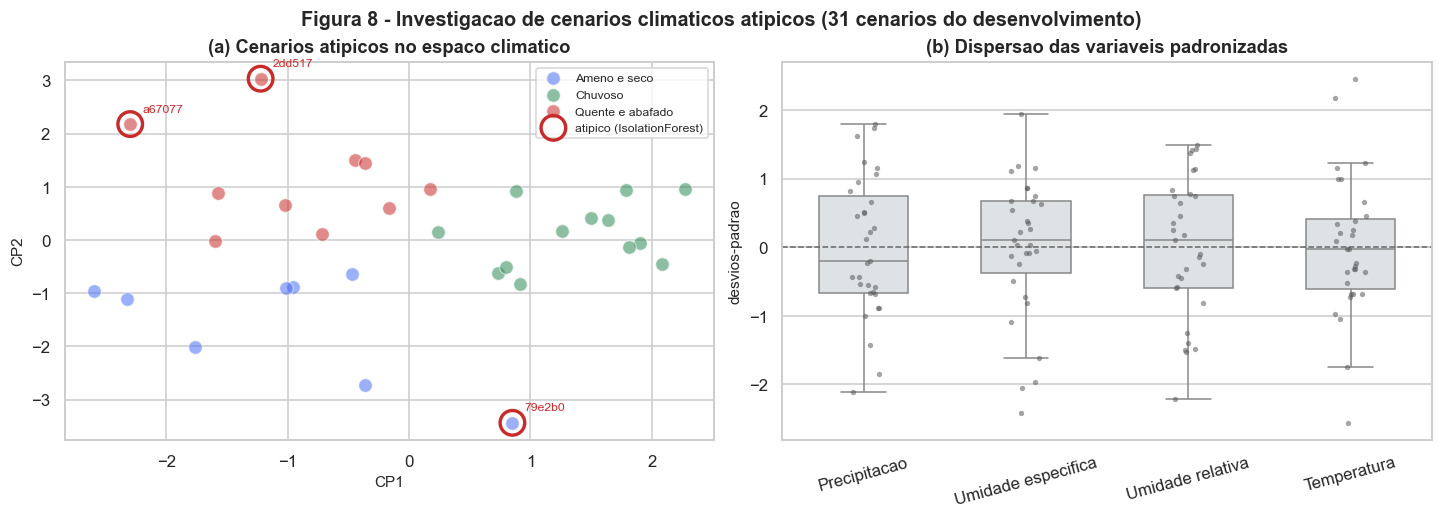

In [27]:
# Figura 8: onde estao os cenarios atipicos.
fig, eixos = plt.subplots(1, 2, figsize=(13, 4.6))

# (a) posicao no espaco de componentes principais
eixo = eixos[0]
for nome in ORDEM_GRUPOS:
    marca = (cenarios_dev["grupo"] == nome).values
    eixo.scatter(pontos_pca[marca, 0], pontos_pca[marca, 1], s=80, alpha=0.55,
                 color=CORES_GRUPO[nome], edgecolor="white", linewidth=0.8, label=nome)
marca_atipico = diagnostico["atipico_isolamento"].values
eixo.scatter(pontos_pca[marca_atipico, 0], pontos_pca[marca_atipico, 1], s=260,
             facecolor="none", edgecolor="#C92A2A", linewidth=2.2, label="atipico (IsolationForest)")
for i in np.where(marca_atipico)[0]:
    eixo.annotate(diagnostico["cenario"].iloc[i][:6], (pontos_pca[i, 0], pontos_pca[i, 1]),
                  textcoords="offset points", xytext=(8, 8), fontsize=8, color="#C92A2A")
eixo.set_xlabel("CP1")
eixo.set_ylabel("CP2")
eixo.set_title("(a) Cenarios atipicos no espaco climatico")
eixo.legend(fontsize=8, loc="best")

# (b) diagrama de caixa de cada variavel padronizada, com os pontos marcados
eixo = eixos[1]
padronizado_longo = pd.DataFrame(X_cenarios, columns=[ROTULO_CLIMA[v] for v in VAR_CLIMA]).melt(
    var_name="variavel", value_name="valor_padronizado")
sns.boxplot(data=padronizado_longo, x="variavel", y="valor_padronizado",
            color="#DEE2E6", width=0.55, showfliers=False, ax=eixo)
sns.stripplot(data=padronizado_longo, x="variavel", y="valor_padronizado",
              color="0.35", size=3.5, alpha=0.55, ax=eixo)
eixo.axhline(0, color="0.4", linewidth=1, linestyle="--")
eixo.set_xlabel("")
eixo.set_ylabel("desvios-padrao")
eixo.set_title("(b) Dispersao das variaveis padronizadas")
eixo.tick_params(axis="x", labelrotation=15)

fig.suptitle("Figura 8 - Investigacao de cenarios climaticos atipicos (31 cenarios do desenvolvimento)",
             fontsize=13, fontweight="bold")
salvar_figura(fig, "fig08_outliers_clima")
plt.show()

### O que esses cenários são

Os três cenários com os menores escores do IsolationForest ficam nos **extremos do eixo de calor**:

- **`79e2b0`** (temperatura 25,56 °C, umidade específica 17,61 g/kg): o cenário mais frio e de ar
  mais seco do conjunto — e, ainda assim, com precipitação acima da média (2.592).
- **`2dd517`** (26,79 °C, 18,70 g/kg) e **`a67077`** (26,72 °C, 18,51 g/kg): os dois cenários mais
  quentes e de ar mais úmido.

Os valores estão dentro de faixas usuais para clima tropical úmido e são internamente coerentes com
a relação psicrométrica (ar mais quente comporta mais vapor). **Não há sinal evidente de erro** —
nenhum valor impossível, nenhuma ordem de grandeza fora de lugar, nenhuma inconsistência interna.

É importante notar o que isso não é: **a ausência de sinal de erro não equivale a validação**. Não
temos a fonte primária dos dados, nem instrumentação, nem qualquer registro externo contra o qual
conferir. Não é possível afirmar que estejam corretos.

**Decisão: manter todas as observações — por falta de justificativa para excluí-las**, e não por
prova de correção. Excluí-las estreitaria ainda mais uma faixa climática que já é estreita, e são
justamente os extremos que dão ao modelo alguma amplitude para relacionar clima e rendimento.

Vale registrar a ligação com a seção 6.2: os dois cenários mais frios (`79e2b0` e `eb5cfe`) são os
mesmos que formavam o grupo de dois pontos em k = 4.

## 7.2 Rendimentos atípicos dentro de cada cultura

In [28]:
# Dois criterios aplicados SEPARADAMENTE dentro de cada cultura.
# Comparar o rendimento de um cacau com o de um dende nao faz sentido: sao escalas diferentes.
resumo_outliers, marcados_rendimento = [], []

for cultura, grupo in desenvolvimento.groupby("cultura"):
    valores = grupo[ALVO]

    # Criterio A - IQR dentro da cultura
    q1, q3 = valores.quantile([0.25, 0.75])
    intervalo = q3 - q1
    inferior, superior = q1 - 1.5 * intervalo, q3 + 1.5 * intervalo
    fora_iqr = (valores < inferior) | (valores > superior)

    # Criterio B - escore z robusto (mediana e desvio absoluto mediano), limiar usual de 3,5
    mediana = valores.median()
    desvio_absoluto = (valores - mediana).abs().median()
    escore_z = 0.6745 * (valores - mediana) / desvio_absoluto
    fora_z = escore_z.abs() > 3.5

    resumo_outliers.append({
        "cultura": cultura, "n": len(grupo), "mediana": mediana,
        "limite_inferior_IQR": inferior, "limite_superior_IQR": superior,
        "n_fora_IQR": int(fora_iqr.sum()), "n_fora_z_robusto": int(fora_z.sum()),
        "maior_|z|": float(escore_z.abs().max()),
    })
    selecionados = grupo[fora_iqr | fora_z]
    if len(selecionados):
        marcados_rendimento.append(selecionados.assign(z_robusto=escore_z[fora_iqr | fora_z]))

display(pd.DataFrame(resumo_outliers).round(2))

if marcados_rendimento:
    print("Registros marcados:")
    display(pd.concat(marcados_rendimento))
else:
    print("RESULTADO: nenhum rendimento atipico dentro de nenhuma cultura,")
    print("por nenhum dos dois criterios. O maior escore z robusto observado foi",
          round(max(r["maior_|z|"] for r in resumo_outliers), 2), "- bem abaixo do limiar 3,5.")

,cultura,n,mediana,limite_inferior_IQR,limite_superior_IQR,n_fora_IQR,n_fora_z_robusto,maior_|z|
0,"Cocoa, beans",31,8300.0,4507.75,12737.75,0,0,1.89
1,Oil palm fruit,31,169783.0,137048.75,211630.75,0,0,2.15
2,"Rice, paddy",31,30676.0,18611.00,45299.00,0,0,2.69
3,"Rubber, natural",31,6913.0,1956.00,13648.00,0,0,1.86


RESULTADO: nenhum rendimento atipico dentro de nenhuma cultura,
por nenhum dos dois criterios. O maior escore z robusto observado foi 2.69 - bem abaixo do limiar 3,5.


In [29]:
# O erro a evitar: aplicar o mesmo criterio ao rendimento SEM separar por cultura.
q1_global, q3_global = desenvolvimento[ALVO].quantile([0.25, 0.75])
intervalo_global = q3_global - q1_global
inferior_global = q1_global - 1.5 * intervalo_global
superior_global = q3_global + 1.5 * intervalo_global
marcados_global = (desenvolvimento[ALVO] < inferior_global) | (desenvolvimento[ALVO] > superior_global)

print("Limites do IQR calculados sobre TODAS as culturas juntas: [{:,.0f} ; {:,.0f}]".format(
    inferior_global, superior_global))
print("Linhas marcadas como atipicas:", int(marcados_global.sum()), "de", len(desenvolvimento))
print("Distribuicao dessas linhas por cultura:",
      desenvolvimento[marcados_global]["cultura"].value_counts().to_dict())

Limites do IQR calculados sobre TODAS as culturas juntas: [-80,853 ; 156,542]
Linhas marcadas como atipicas: 27 de 124
Distribuicao dessas linhas por cultura: {'Oil palm fruit': 27}


figura salva: docs\figuras\fig09_outliers_rendimento.png


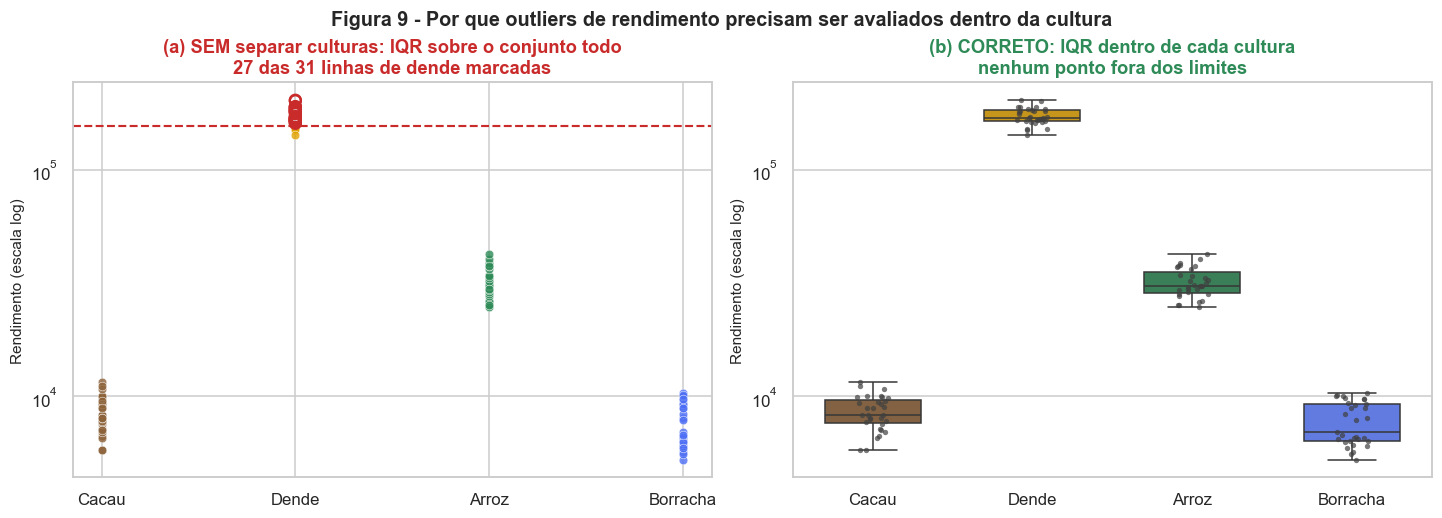

In [30]:
# Figura 9: os dois criterios lado a lado.
fig, eixos = plt.subplots(1, 2, figsize=(13, 4.6))

# (a) criterio global - marca uma cultura inteira
eixo = eixos[0]
for i, cultura in enumerate(ordem):
    sub = desenvolvimento[desenvolvimento["cultura"] == cultura]
    marcado = (sub[ALVO] < inferior_global) | (sub[ALVO] > superior_global)
    eixo.scatter(np.full(int((~marcado).sum()), i), sub.loc[~marcado, ALVO], s=32,
                 color=CORES_CULTURA[cultura], alpha=0.8, edgecolor="white", linewidth=0.4)
    eixo.scatter(np.full(int(marcado.sum()), i), sub.loc[marcado, ALVO], s=52,
                 facecolor="none", edgecolor="#C92A2A", linewidth=1.5)
eixo.axhline(superior_global, color="#C92A2A", linestyle="--", linewidth=1.4)
eixo.set_yscale("log")
eixo.set_xticks(range(len(ordem)))
eixo.set_xticklabels([ROTULO_CURTO[c] for c in ordem])
eixo.set_ylabel("Rendimento (escala log)")
eixo.set_title("(a) SEM separar culturas: IQR sobre o conjunto todo\n"
               "27 das 31 linhas de dende marcadas", color="#C92A2A")

# (b) criterio dentro de cada cultura
eixo = eixos[1]
sns.boxplot(data=desenvolvimento, x="cultura", y=ALVO, order=ordem,
            hue="cultura", palette=paleta, legend=False, width=0.6, ax=eixo)
sns.stripplot(data=desenvolvimento, x="cultura", y=ALVO, order=ordem,
              color="0.25", size=3.5, alpha=0.7, ax=eixo)
eixo.set_yscale("log")
eixo.set_xticks(range(len(ordem)))
eixo.set_xticklabels([ROTULO_CURTO[c] for c in ordem])
eixo.set_xlabel("")
eixo.set_ylabel("Rendimento (escala log)")
eixo.set_title("(b) CORRETO: IQR dentro de cada cultura\nnenhum ponto fora dos limites", color="#2E8B57")

fig.suptitle("Figura 9 - Por que outliers de rendimento precisam ser avaliados dentro da cultura",
             fontsize=13, fontweight="bold")
salvar_figura(fig, "fig09_outliers_rendimento")
plt.show()

### Conclusão sobre outliers

**Os dois critérios aplicados não identificaram outliers de rendimento nas 124 linhas de
desenvolvimento, quando avaliadas dentro de cada cultura.** IQR e escore z robusto concordam: zero
marcações nas quatro culturas, com o maior escore z robusto observado (2,69) abaixo do limiar de
3,5. Isso é o que estes dois critérios dizem sobre estas 124 linhas — não uma garantia de que não
haja observações problemáticas por outros critérios ou no conjunto reservado.

O painel (a) da Figura 9 mostra o que aconteceria com o critério aplicado ao conjunto todo, sem
separar culturas: **27 das 31 linhas de dendê do desenvolvimento seriam marcadas como anômalas**.
Isso não seria detecção de anomalia; seria a constatação, disfarçada de anomalia, de que o dendê
opera numa escala maior que as demais culturas. Removê-las eliminaria quase toda uma cultura do
problema.

**Resumo das decisões:**

| Item | Decisão | Justificativa |
| --- | --- | --- |
| 3 cenários climáticos extremos | **Mantidos** | Sem justificativa para excluir: valores em faixas usuais e internamente coerentes, ainda que não validados externamente |
| Rendimentos por cultura | **Nenhum marcado** | IQR e escore z robusto, zero marcações nas 124 linhas |
| Critério global de rendimento | **Rejeitado** | Marcaria 27 das 31 linhas de dendê; confunde diferença de escala com anomalia |

---
# 8. Comparação inicial dos cinco regressores

> **Situação desta seção.** É um **resultado inicial preparado para a revisão da frente ML**, não uma
> escolha definitiva. Nenhum número aqui vem do conjunto de teste, que permanece lacrado.

## 8.1 Protocolo

Os cinco algoritmos exigidos pelo enunciado, mais duas referências:

| # | Alternativa | Papel |
| --- | --- | --- |
| — | `DummyRegressor` (média global) | Referência mínima: piso absoluto de desempenho |
| — | Média da cultura | **Referência que interessa:** o quanto se acerta sabendo *só* a cultura |
| 1 | `LinearRegression` | Regressão linear |
| 2 | `DecisionTreeRegressor` | Árvore de decisão |
| 3 | `RandomForestRegressor` | Floresta aleatória |
| 4 | `KNeighborsRegressor` | K vizinhos mais próximos |
| 5 | `SVR` (núcleo RBF) | Máquina de vetores de suporte para regressão |

### Validação cruzada agrupada **aninhada**

A busca de hiperparâmetros e a medição do desempenho não podem usar os mesmos dados. Se o mesmo
conjunto escolhe os parâmetros e depois avalia o resultado dessa escolha, a métrica reportada
incorpora o ganho da própria seleção e fica otimista.

O desenho adotado separa as duas coisas:

```
para cada uma das 5 partições EXTERNAS (GroupKFold, agrupado por cenário):
    ├── treino externo  ──► busca de hiperparâmetros com GroupKFold de 3 partições INTERNAS
    │                        (também agrupadas por cenário, só com dados de treino)
    │                        └── devolve a melhor configuração PARA ESTA partição
    └── validação externa ──► previsão, nunca vista pela busca
```

As **cinco partições externas são exatamente as mesmas** já registradas em `PARTICOES` e no
`docs/protocolo_divisao.json` — a divisão dos dados não mudou.

Consequência a ter em mente: cada partição externa pode escolher hiperparâmetros diferentes. Isso é
esperado, e a variação entre elas é em si um indicador de estabilidade — está reportada adiante.

**O que este desenho ainda não resolve:** escolher a alternativa vencedora olhando estas mesmas
métricas continua sendo uma seleção. A confirmação independente depende do teste reservado, que
permanece lacrado (seção 9).

Referência:
[scikit-learn — validação aninhada](https://scikit-learn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html)

**Demais regras, comuns a todas as alternativas:**

- Entradas: `cultura` (codificada one-hot) e as quatro variáveis climáticas. O identificador de
  cenário **não** é entrada de nenhum modelo.
- Toda transformação (codificação, escalonamento, escalonamento do alvo do SVR) vive **dentro do
  pipeline** e é reajustada em cada partição, apenas com dados de treino.
- Escalonamento das variáveis climáticas aplicado onde importa (linear, KNN, SVR). Árvores e
  florestas são invariantes a transformações monotônicas e recebem os valores originais.
  As colunas one-hot da cultura **não** passam por escalonamento em nenhum caso.
- **Uma única função de métricas** para todas as alternativas.
- Busca pequena e deliberada (2 a 4 valores por parâmetro).

In [31]:
# ============================================================
# 8. COMPARACAO DOS REGRESSORES
# ============================================================
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor, NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

# Nivel unico de paralelismo do notebook.
# Com 124 linhas o custo e baixo e a execucao sequencial evita o encadeamento de processos
# do joblib/loky (que no Windows deixa rastros de encerramento no terminal).
N_JOBS = 1

# Numero de particoes da busca INTERNA. Tres mantem cerca de 8 cenarios por particao interna,
# respeitando o numero de grupos disponivel dentro de cada treino externo.
N_PARTICOES_INTERNAS = 3

X_dev = desenvolvimento[VAR_CATEGORICA + VAR_CLIMA]
y_dev = desenvolvimento[ALVO].to_numpy()
grupos_dev = desenvolvimento["cenario"].to_numpy()


def calcular_metricas(observado, previsto):
    """Funcao unica de metricas, usada por TODAS as alternativas.

    MAE e RMSE ficam na unidade original do arquivo (ver duvida de unidade na secao 3.3).
    MAPE e adimensional e permite comparar culturas de magnitudes muito diferentes.
    """
    return {
        "MAE": mean_absolute_error(observado, previsto),
        "RMSE": float(np.sqrt(mean_squared_error(observado, previsto))),
        "R2": r2_score(observado, previsto),
        "MAPE_%": float(np.mean(np.abs((observado - previsto) / observado)) * 100),
    }


class MediaDaCultura(BaseEstimator, RegressorMixin):
    """Referencia que preve o rendimento medio da cultura, aprendido SOMENTE no treino de cada particao.

    E a comparacao que realmente importa: se um modelo com as variaveis climaticas nao superar
    esta referencia, entao o clima nao esta acrescentando informacao alem de identificar a cultura.
    """

    def fit(self, X, y):
        serie = pd.Series(np.asarray(y), index=np.asarray(X["cultura"]))
        self.medias_ = serie.groupby(level=0).mean().to_dict()   # media por cultura vista no treino
        self.media_global_ = float(np.mean(y))                   # reserva para cultura nao vista
        return self

    def predict(self, X):
        return np.array([self.medias_.get(c, self.media_global_) for c in X["cultura"]])


def montar_preprocessamento(escalonar):
    """One-hot na cultura (sem escalonamento); escalonamento das climaticas so quando o algoritmo precisa."""
    return ColumnTransformer([
        ("categorica", OneHotEncoder(handle_unknown="ignore"), VAR_CATEGORICA),
        ("numerica", StandardScaler() if escalonar else "passthrough", VAR_CLIMA),
    ])


print("Entradas:", list(X_dev.columns))
print("Alvo    :", ALVO)
print("Linhas  :", len(X_dev), "| Particoes externas:", len(PARTICOES),
      "| Particoes internas:", N_PARTICOES_INTERNAS, "| N_JOBS:", N_JOBS)

Entradas: ['cultura', 'precipitacao', 'umidade_especifica', 'umidade_relativa', 'temperatura']
Alvo    : rendimento
Linhas  : 124 | Particoes externas: 5 | Particoes internas: 3 | N_JOBS: 1


In [32]:
def avaliar_aninhado(construir_modelo, grade=None):
    """Executa a validacao cruzada agrupada aninhada e devolve as previsoes externas.

    Em cada particao EXTERNA, a busca de hiperparametros roda em particoes INTERNAS
    formadas apenas com os cenarios do treino externo. A previsao da validacao externa
    nunca foi vista pela busca.

    Devolve: (previsoes externas, metricas por particao, parametros escolhidos em cada particao).
    """
    previsto = np.empty(len(y_dev))
    metricas_particao, parametros_particao = [], []

    for indices_treino, indices_validacao in PARTICOES:
        X_treino = X_dev.iloc[indices_treino]
        y_treino = y_dev[indices_treino]
        grupos_treino = grupos_dev[indices_treino]

        if grade:
            # Particoes internas: agrupadas por cenario, apenas com dados de treino.
            particoes_internas = list(
                GroupKFold(n_splits=N_PARTICOES_INTERNAS).split(X_treino, y_treino, groups=grupos_treino)
            )
            busca = GridSearchCV(construir_modelo(), grade, cv=particoes_internas,
                                 scoring="neg_mean_absolute_error", n_jobs=N_JOBS)
            busca.fit(X_treino, y_treino)
            modelo = busca.best_estimator_
            parametros_particao.append(busca.best_params_)
        else:
            modelo = clone(construir_modelo()).fit(X_treino, y_treino)
            parametros_particao.append({})

        parcial = modelo.predict(X_dev.iloc[indices_validacao])
        previsto[indices_validacao] = parcial
        metricas_particao.append(calcular_metricas(y_dev[indices_validacao], parcial))

    return previsto, pd.DataFrame(metricas_particao), parametros_particao

In [33]:
# Catalogo das alternativas: (construtor do estimador, grade de busca, escalonar climaticas).
# escalonar=None indica uma referencia que nao usa pipeline.
ALTERNATIVAS = {
    "Ref. media global (Dummy)": (
        lambda: DummyRegressor(strategy="mean"), {}, False),
    "Ref. media da cultura": (
        lambda: MediaDaCultura(), {}, None),
    "1. Regressao Linear": (
        lambda: LinearRegression(), {}, True),
    "2. Arvore de Decisao": (
        lambda: DecisionTreeRegressor(random_state=SEED),
        {"modelo__max_depth": [3, 5, 8, None], "modelo__min_samples_leaf": [1, 3, 5]}, False),
    "3. Floresta Aleatoria": (
        lambda: RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=N_JOBS),
        {"modelo__max_depth": [5, 10, None], "modelo__min_samples_leaf": [1, 2, 4]}, False),
    "4. KNN": (
        lambda: KNeighborsRegressor(),
        {"modelo__n_neighbors": [3, 5, 7, 9], "modelo__weights": ["uniform", "distance"]}, True),
    "5. SVR (RBF)": (
        # O SVR e sensivel a escala do ALVO. TransformedTargetRegressor padroniza y dentro do
        # pipeline, ou seja, reajustado a cada particao e apenas com dados de treino.
        lambda: TransformedTargetRegressor(regressor=SVR(kernel="rbf"), transformer=StandardScaler()),
        {"modelo__regressor__C": [1, 10, 100],
         "modelo__regressor__gamma": ["scale", 0.1],
         "modelo__regressor__epsilon": [0.05, 0.1]}, True),
}


def construir(nome):
    """Monta o pipeline completo de uma alternativa do catalogo."""
    estimador, _, escalonar = ALTERNATIVAS[nome]
    if escalonar is None:
        return estimador()
    return Pipeline([("preparacao", montar_preprocessamento(escalonar)), ("modelo", estimador())])


previsoes_validacao = {}   # previsoes EXTERNAS (cada linha prevista por um modelo que nao a viu)
resumo_geral, hiperparametros = [], {}

for nome, (_, grade, _) in ALTERNATIVAS.items():
    previsto, por_particao, parametros = avaliar_aninhado(lambda n=nome: construir(n), grade)
    previsoes_validacao[nome] = previsto
    if grade:
        hiperparametros[nome] = parametros
    resumo_geral.append({
        "Alternativa": nome, **calcular_metricas(y_dev, previsto),
        "MAE_media_particoes": por_particao["MAE"].mean(),
        "MAE_desvio_particoes": por_particao["MAE"].std(),
        "R2_media_particoes": por_particao["R2"].mean(),
        "R2_desvio_particoes": por_particao["R2"].std(),
    })
    print("concluido:", nome)

tabela_geral = pd.DataFrame(resumo_geral).sort_values("MAE").reset_index(drop=True)

concluido: Ref. media global (Dummy)
concluido: Ref. media da cultura
concluido: 1. Regressao Linear


concluido: 2. Arvore de Decisao


concluido: 3. Floresta Aleatoria


concluido: 4. KNN


concluido: 5. SVR (RBF)


In [34]:
print("=== RESULTADO GERAL - previsoes da validacao ANINHADA, 124 linhas do desenvolvimento ===")
print("MAE e RMSE em unidades de rendimento do arquivo (ver secao 3.3).")
print("")
display(tabela_geral.round({"MAE": 0, "RMSE": 0, "R2": 4, "MAPE_%": 2,
                            "MAE_media_particoes": 0, "MAE_desvio_particoes": 0,
                            "R2_media_particoes": 4, "R2_desvio_particoes": 4}))

# A busca roda dentro de cada particao externa, entao pode escolher configuracoes diferentes.
# A estabilidade dessa escolha e informacao util sobre a alternativa.
print("=== Hiperparametros escolhidos em CADA particao externa ===")
for nome, lista in hiperparametros.items():
    distintas = {str(p) for p in lista}
    print("\n ", nome, "- configuracoes distintas entre as 5 particoes:", len(distintas))
    for i, parametros in enumerate(lista):
        print("     particao", i, "->", parametros)

=== RESULTADO GERAL - previsoes da validacao ANINHADA, 124 linhas do desenvolvimento ===
MAE e RMSE em unidades de rendimento do arquivo (ver secao 3.3).



,Alternativa,MAE,RMSE,R2,MAPE_%,MAE_media_particoes,MAE_desvio_particoes,R2_media_particoes,R2_desvio_particoes
0,3. Floresta Aleatoria,3597.0,6804.0,0.9903,11.15,3564.0,889.0,0.9905,0.0056
1,Ref. media da cultura,4772.0,7846.0,0.9871,14.24,4751.0,666.0,0.9871,0.0028
2,2. Arvore de Decisao,4800.0,9364.0,0.9817,13.03,4790.0,384.0,0.9818,0.0048
3,1. Regressao Linear,5025.0,7915.0,0.9869,19.53,5007.0,795.0,0.9870,0.0041
4,4. KNN,6759.0,15723.0,0.9483,35.39,6592.0,5266.0,0.9515,0.0600
5,5. SVR (RBF),7365.0,11001.0,0.9747,39.56,7257.0,2996.0,0.9753,0.0162
6,Ref. media global (Dummy),58898.0,69146.0,-0.0002,340.85,58894.0,632.0,-0.0005,0.0007


=== Hiperparametros escolhidos em CADA particao externa ===

  2. Arvore de Decisao - configuracoes distintas entre as 5 particoes: 4
     particao 0 -> {'modelo__max_depth': 5, 'modelo__min_samples_leaf': 5}
     particao 1 -> {'modelo__max_depth': 8, 'modelo__min_samples_leaf': 5}
     particao 2 -> {'modelo__max_depth': 5, 'modelo__min_samples_leaf': 3}
     particao 3 -> {'modelo__max_depth': 8, 'modelo__min_samples_leaf': 1}
     particao 4 -> {'modelo__max_depth': 8, 'modelo__min_samples_leaf': 5}

  3. Floresta Aleatoria - configuracoes distintas entre as 5 particoes: 4
     particao 0 -> {'modelo__max_depth': 10, 'modelo__min_samples_leaf': 2}
     particao 1 -> {'modelo__max_depth': None, 'modelo__min_samples_leaf': 1}
     particao 2 -> {'modelo__max_depth': 10, 'modelo__min_samples_leaf': 1}
     particao 3 -> {'modelo__max_depth': 5, 'modelo__min_samples_leaf': 1}
     particao 4 -> {'modelo__max_depth': None, 'modelo__min_samples_leaf': 1}

  4. KNN - configuracoes distint

### 8.2 O R² geral não basta para comparar as alternativas

Olhe a coluna `R2`: **seis das sete alternativas ficam entre 0,948 e 0,990**. Um relatório
descuidado escreveria "todos os modelos explicam mais de 94% da variância do rendimento" e passaria
adiante.

Mas a referência **média da cultura** — que ignora completamente o clima e apenas devolve a média
da cultura vista no treino — atinge **R² = 0,987**. Ela não usa nenhuma variável climática. Isso não
torna o R² uma métrica inútil: ele apenas não é suficiente, **isoladamente**, para dizer se um modelo
acrescenta algo além de distinguir quatro culturas de escalas muito diferentes. Para essa pergunta,
é preciso comparar contra a referência e olhar dentro de cada cultura.

A comparação informativa é contra a referência da cultura, e não contra o `DummyRegressor`:

| Alternativa | MAE | vs. média da cultura |
| --- | --- | --- |
| **Floresta Aleatória** | **3.597** | **−24,6%** (melhor) |
| *Ref. média da cultura* | *4.772* | *referência* |
| Árvore de Decisão | 4.800 | +0,6% |
| Regressão Linear | 5.025 | +5,3% |
| KNN | 6.759 | +41,6% |
| SVR (RBF) | 7.365 | +54,3% |
| *Ref. média global (Dummy)* | *58.898* | *+1.134%* |

**Quatro dos cinco algoritmos não superam, no conjunto, a referência que só usa a cultura.**

> **O que mudou com a validação aninhada.** Numa versão anterior deste notebook a busca de
> hiperparâmetros usava as mesmas partições da avaliação. A árvore de decisão aparecia com MAE 4.340,
> **abaixo** da referência; com a busca movida para dentro do treino de cada partição, seu MAE passou
> a 4.800, **acima** da referência. A ordem entre alternativas mudou. A Floresta Aleatória foi de
> 3.551 para 3.597. Regressão linear, KNN e SVR não mudaram — a primeira não tem busca, e as outras
> duas escolheram a mesma configuração em todas as partições.

### Estabilidade da escolha de hiperparâmetros

A saída acima mostra quantas configurações distintas cada alternativa escolheu entre as cinco
partições externas:

- **KNN e SVR**: a mesma configuração nas cinco partições — escolha estável.
- **Floresta Aleatória**: quatro configurações distintas (`max_depth` variando entre 5, 10 e `None`).
- **Árvore de Decisão**: quatro configurações distintas.

Nos dois últimos casos a escolha depende de quais cenários caem no treino, o que é coerente com o
tamanho da amostra e reforça a cautela ao interpretar diferenças pequenas entre alternativas.

## 8.3 A pergunta central: o clima acrescenta informação dentro de cada cultura?

In [35]:
# Metricas calculadas SEPARADAMENTE dentro de cada cultura, a partir das previsoes externas.
linhas_por_cultura = []
for nome, previsto in previsoes_validacao.items():
    quadro = desenvolvimento.assign(previsto=previsto)
    for cultura, grupo in quadro.groupby("cultura"):
        linhas_por_cultura.append({
            "Alternativa": nome, "cultura": cultura,
            **calcular_metricas(grupo[ALVO].to_numpy(), grupo["previsto"].to_numpy()),
        })
metricas_cultura = pd.DataFrame(linhas_por_cultura)

NOME_REFERENCIA = "Ref. media da cultura"
ordem_tabela = tabela_geral["Alternativa"].tolist()

for metrica, casas in [("MAE", 0), ("R2", 3), ("MAPE_%", 2)]:
    tabela = (metricas_cultura.pivot(index="Alternativa", columns="cultura", values=metrica)
              .reindex(ordem_tabela).rename(columns=ROTULO_CURTO))
    titulo = {"MAE": "MAE dentro da cultura (unidades do arquivo) - menor e melhor",
              "R2": "R2 dentro da cultura - maior e melhor",
              "MAPE_%": "Erro percentual medio dentro da cultura (%)"}[metrica]
    print("===", titulo, "===")
    display(tabela.round(casas))

=== MAE dentro da cultura (unidades do arquivo) - menor e melhor ===


cultura,Cacau,Dende,Arroz,Borracha
Alternativa,,,,
3. Floresta Aleatoria,1113.0,9418.0,2508.0,1348.0
Ref. media da cultura,1298.0,12288.0,3884.0,1616.0
2. Arvore de Decisao,1342.0,13549.0,2933.0,1376.0
1. Regressao Linear,2215.0,11973.0,3385.0,2526.0
4. KNN,5956.0,12684.0,5359.0,3036.0
5. SVR (RBF),5456.0,13541.0,5181.0,5281.0
Ref. media global (Dummy),46764.0,117829.0,23397.0,47602.0


=== R2 dentro da cultura - maior e melhor ===


cultura,Cacau,Dende,Arroz,Borracha
Alternativa,,,,
3. Floresta Aleatoria,0.099,0.199,0.449,0.020
Ref. media da cultura,-0.092,-0.039,-0.015,-0.153
2. Arvore de Decisao,-0.157,-0.567,0.292,-0.138
1. Regressao Linear,-2.601,-0.013,0.096,-2.705
4. KNN,-116.060,-1.446,-5.222,-30.936
5. SVR (RBF),-35.275,-0.369,-1.207,-24.772
Ref. media global (Dummy),-1013.232,-65.982,-25.252,-837.448


=== Erro percentual medio dentro da cultura (%) ===


cultura,Cacau,Dende,Arroz,Borracha
Alternativa,,,,
3. Floresta Aleatoria,12.91,5.52,7.90,18.26
Ref. media da cultura,15.98,7.15,12.26,21.59
2. Arvore de Decisao,16.35,7.78,9.12,18.87
1. Regressao Linear,26.31,7.00,10.88,33.91
4. KNN,69.37,7.20,18.51,46.50
5. SVR (RBF),61.33,7.81,16.97,72.11
Ref. media global (Dummy),567.79,67.82,76.94,650.83


In [36]:
# ------------------------------------------------------------
# Comparacao explicita com a REFERENCIA, cultura a cultura.
# Gerada por codigo para nao haver divergencia entre tabela e texto.
#
# Atencao ao ponto de leitura: um R2 negativo NAO significa perder para a referencia.
# O zero do R2 corresponde a media da propria cultura NO CONJUNTO AVALIADO, enquanto a
# referencia do projeto usa medias aprendidas no treino de cada particao - por isso ela
# mesma tem R2 levemente negativo. A comparacao correta e contra a referencia, nao contra zero.
# ------------------------------------------------------------
referencia_cultura = metricas_cultura[metricas_cultura["Alternativa"] == NOME_REFERENCIA].set_index("cultura")

def comparar_com_referencia(metrica, menor_e_melhor):
    valores = (metricas_cultura.pivot(index="Alternativa", columns="cultura", values=metrica)
               .reindex(ordem_tabela))
    alvo = referencia_cultura[metrica]
    return (valores.lt(alvo, axis=1) if menor_e_melhor else valores.gt(alvo, axis=1))

supera_mae = comparar_com_referencia("MAE", menor_e_melhor=True)
supera_r2 = comparar_com_referencia("R2", menor_e_melhor=False)

print("=== Supera a referencia da media da cultura? (criterio: MAE menor) ===")
display(supera_mae.rename(columns=ROTULO_CURTO).replace({True: "SIM", False: "nao"}))
print("=== Mesmo julgamento pelo criterio R2 maior ===")
display(supera_r2.rename(columns=ROTULO_CURTO).replace({True: "SIM", False: "nao"}))

# Onde os dois criterios discordam, a conclusao depende da metrica escolhida.
divergencia = supera_mae != supera_r2
if divergencia.to_numpy().any():
    print("ATENCAO - os dois criterios discordam nestes casos:")
    for alternativa, cultura in zip(*np.where(divergencia)):
        print("   {:28s} {:16s} MAE diz {:3s} | R2 diz {}".format(
            divergencia.index[alternativa], ROTULO_CURTO[divergencia.columns[cultura]],
            "SIM" if supera_mae.iloc[alternativa, cultura] else "nao",
            "SIM" if supera_r2.iloc[alternativa, cultura] else "nao"))
else:
    print("Os dois criterios concordam em todas as celulas desta tabela.")

print("")
print("Resumo pelo criterio MAE - em quantas das 4 culturas cada alternativa supera a referencia:")
contagem = supera_mae.drop(index=[NOME_REFERENCIA]).sum(axis=1).sort_values(ascending=False)
display(contagem.rename("culturas_superadas").to_frame())

=== Supera a referencia da media da cultura? (criterio: MAE menor) ===


cultura,Cacau,Dende,Arroz,Borracha
Alternativa,,,,
3. Floresta Aleatoria,SIM,SIM,SIM,SIM
Ref. media da cultura,nao,nao,nao,nao
2. Arvore de Decisao,nao,nao,SIM,SIM
1. Regressao Linear,nao,SIM,SIM,nao
4. KNN,nao,nao,nao,nao
5. SVR (RBF),nao,nao,nao,nao
Ref. media global (Dummy),nao,nao,nao,nao


=== Mesmo julgamento pelo criterio R2 maior ===


cultura,Cacau,Dende,Arroz,Borracha
Alternativa,,,,
3. Floresta Aleatoria,SIM,SIM,SIM,SIM
Ref. media da cultura,nao,nao,nao,nao
2. Arvore de Decisao,nao,nao,SIM,SIM
1. Regressao Linear,nao,SIM,SIM,nao
4. KNN,nao,nao,nao,nao
5. SVR (RBF),nao,nao,nao,nao
Ref. media global (Dummy),nao,nao,nao,nao


Os dois criterios concordam em todas as celulas desta tabela.

Resumo pelo criterio MAE - em quantas das 4 culturas cada alternativa supera a referencia:


,culturas_superadas
Alternativa,
3. Floresta Aleatoria,4
2. Arvore de Decisao,2
1. Regressao Linear,2
4. KNN,0
5. SVR (RBF),0
Ref. media global (Dummy),0


figura salva: docs\figuras\fig10_comparacao_modelos.png


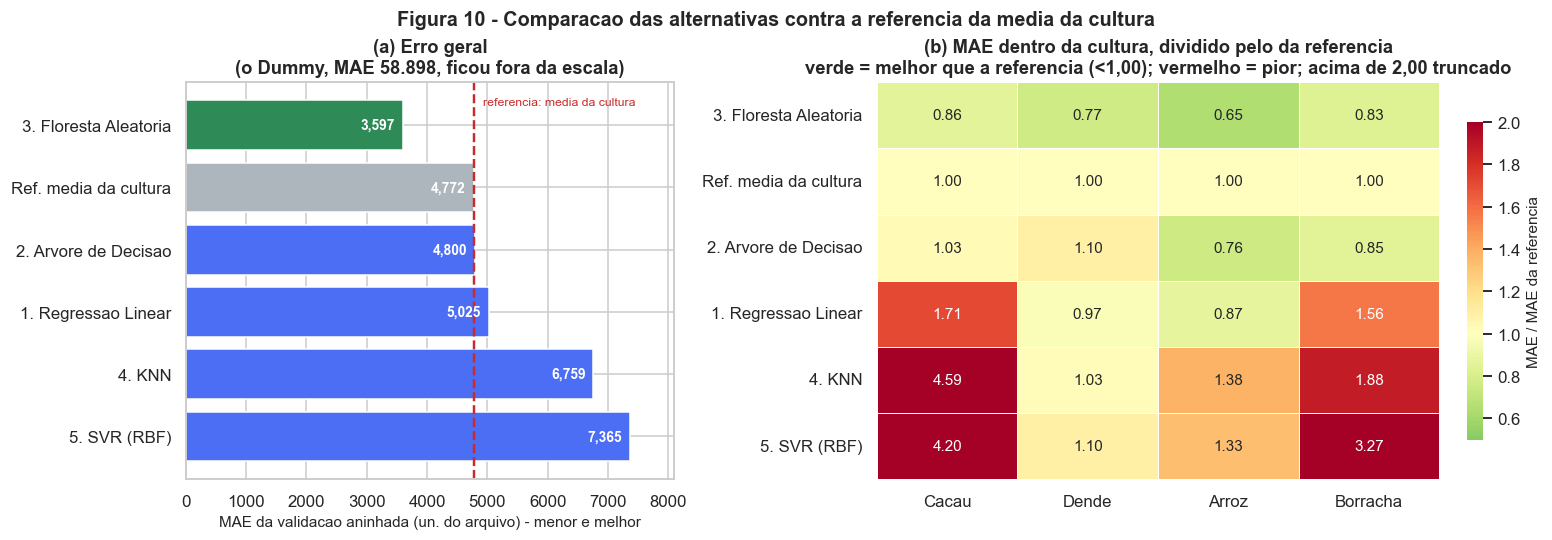

In [37]:
# Figura 10: comparacao geral e comparacao dentro da cultura, lado a lado.
fig, eixos = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={"width_ratios": [1, 1.15]})

# (a) MAE geral, com a referencia da media da cultura destacada
eixo = eixos[0]
sem_dummy = tabela_geral[tabela_geral["Alternativa"] != "Ref. media global (Dummy)"]
cores_barra = ["#ADB5BD" if a.startswith("Ref.") else "#4C6EF5" for a in sem_dummy["Alternativa"]]
cores_barra[list(sem_dummy.index).index(sem_dummy["MAE"].idxmin())] = "#2E8B57"
barras = eixo.barh(sem_dummy["Alternativa"], sem_dummy["MAE"], color=cores_barra, edgecolor="white")
mae_referencia = float(tabela_geral.loc[tabela_geral["Alternativa"] == NOME_REFERENCIA, "MAE"].iloc[0])
eixo.axvline(mae_referencia, color="#C92A2A", linestyle="--", linewidth=1.6)
eixo.annotate("referencia: media da cultura", xy=(mae_referencia, 1.0),
              xycoords=("data", "axes fraction"), xytext=(6, -10), textcoords="offset points",
              color="#C92A2A", fontsize=8, ha="left", va="top")
for barra, valor in zip(barras, sem_dummy["MAE"]):
    eixo.text(valor - 130, barra.get_y() + barra.get_height() / 2, "{:,.0f}".format(valor),
              va="center", ha="right", fontsize=9, color="white", fontweight="bold")
eixo.invert_yaxis()
eixo.set_xlabel("MAE da validacao aninhada (un. do arquivo) - menor e melhor")
eixo.set_title("(a) Erro geral\n(o Dummy, MAE 58.898, ficou fora da escala)")
eixo.set_xlim(0, sem_dummy["MAE"].max() * 1.10)

# (b) MAE dentro de cada cultura, em relacao a referencia (razao)
eixo = eixos[1]
mae_cultura = (metricas_cultura.pivot(index="Alternativa", columns="cultura", values="MAE")
               .reindex(ordem_tabela).drop(index="Ref. media global (Dummy)"))
razao = mae_cultura.div(referencia_cultura["MAE"], axis=1).rename(columns=ROTULO_CURTO)
sns.heatmap(razao, annot=True, fmt=".2f", cmap="RdYlGn_r", center=1.0, vmin=0.5, vmax=2.0,
            linewidths=0.6, cbar_kws={"shrink": 0.8, "label": "MAE / MAE da referencia"}, ax=eixo)
eixo.set_title("(b) MAE dentro da cultura, dividido pelo da referencia\n"
               "verde = melhor que a referencia (<1,00); vermelho = pior; acima de 2,00 truncado")
eixo.set_ylabel("")
eixo.set_xlabel("")

fig.suptitle("Figura 10 - Comparacao das alternativas contra a referencia da media da cultura",
             fontsize=13, fontweight="bold")
salvar_figura(fig, "fig10_comparacao_modelos")
plt.show()

### Leitura da Figura 10 — o resultado principal desta etapa

**A métrica usada para dizer "supera a referência" é o MAE dentro da cultura** (menor é melhor).
Nesta execução o julgamento pelo R² coincidiu com o do MAE em todas as células da tabela, mas as
duas métricas podem discordar — a comparação com transformação logarítmica, na seção 8.5, é um caso
em que discordam —, por isso a métrica fica declarada e as duas tabelas são exibidas.

| Alternativa | Cacau | Dendê | Arroz | Borracha | Culturas superadas |
| --- | --- | --- | --- | --- | --- |
| **Floresta Aleatória** | **1.113** | **9.418** | **2.508** | **1.348** | **4 de 4** |
| *Ref. média da cultura* | *1.298* | *12.288* | *3.884* | *1.616* | *referência* |
| Árvore de Decisão | 1.342 | 13.549 | **2.933** | **1.376** | 2 de 4 |
| Regressão Linear | 2.215 | **11.973** | **3.385** | 2.526 | 2 de 4 |
| SVR (RBF) | 5.456 | 13.541 | 5.181 | 5.281 | 0 de 4 |
| KNN | 5.956 | 12.684 | 5.359 | 3.036 | 0 de 4 |

**Três leituras:**

1. **A Floresta Aleatória é a única alternativa que supera a referência nas quatro culturas.** A
   maior margem aparece no arroz (MAE 35% menor que o da referência), a cultura que as seções 5.4 e
   6.4 já apontavam como a mais associada às variáveis climáticas nesta amostra. São três análises
   complementares sobre os mesmos dados apontando na mesma direção — o que aumenta a coerência
   interna do resultado, sem constituir confirmação independente.

2. **Árvore de decisão e regressão linear superam a referência em duas culturas cada, mas em
   culturas diferentes** — a árvore em arroz e borracha, a linear em dendê e arroz. Nenhuma das duas
   é uniformemente melhor nem uniformemente pior que a referência.

3. **KNN e SVR ficam abaixo da referência em todas as culturas.** A seção 8.4 investiga o
   comportamento do KNN.

> **Por que a referência tem R² negativo em todas as culturas.** Ela prevê a média da cultura
> calculada *no treino de cada partição*, enquanto o zero do R² corresponde à média da cultura *no
> conjunto avaliado*. A pequena diferença entre as duas produz valores em torno de −0,02 a −0,15.
> Por isso **um R² negativo não significa, por si só, perder para a referência**: a regressão linear
> tem R² = −0,013 no dendê e ainda assim supera a referência, cujo R² ali é −0,039.

Alternativa com menor MAE na validacao aninhada: 3. Floresta Aleatoria


figura salva: docs\figuras\fig11_diagnostico_floresta.png


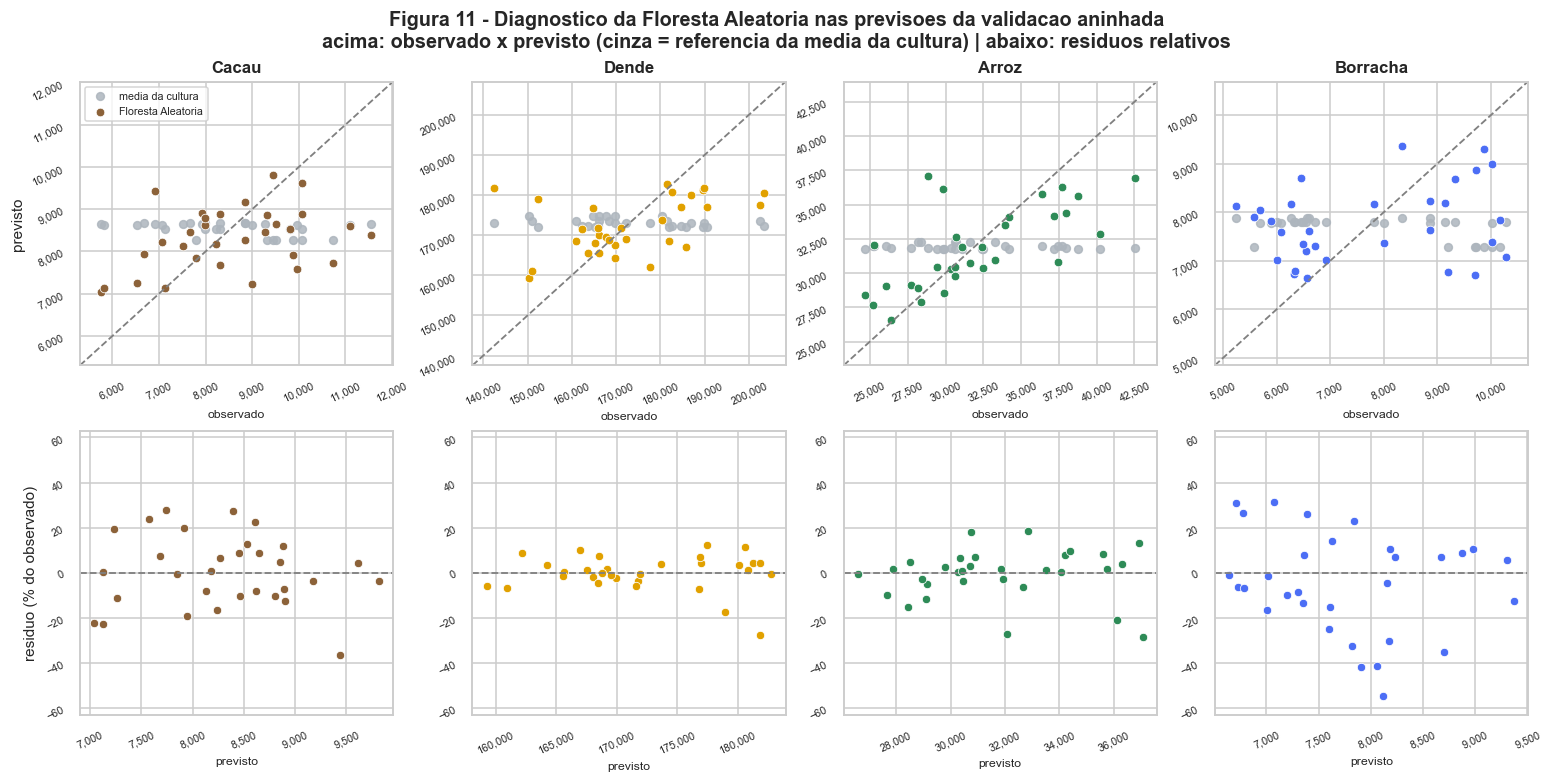

In [38]:
# Figura 11: diagnostico da melhor alternativa (Floresta Aleatoria) contra a referencia.
melhor_nome = tabela_geral.loc[tabela_geral["MAE"].idxmin(), "Alternativa"]
print("Alternativa com menor MAE na validacao aninhada:", melhor_nome)

diagnostico_modelo = desenvolvimento.assign(
    previsto=previsoes_validacao[melhor_nome],
    previsto_referencia=previsoes_validacao[NOME_REFERENCIA],
)
diagnostico_modelo["residuo"] = diagnostico_modelo[ALVO] - diagnostico_modelo["previsto"]
diagnostico_modelo["residuo_%"] = diagnostico_modelo["residuo"] / diagnostico_modelo[ALVO] * 100

# Limite vertical comum aos quatro paineis de residuo, calculado a partir dos dados
# com folga, para que nenhum ponto fique cortado na borda.
limite_residuo = float(np.abs(diagnostico_modelo["residuo_%"]).max()) * 1.15

fig, eixos = plt.subplots(2, 4, figsize=(14, 7))
for j, cultura in enumerate(ordem):
    sub = diagnostico_modelo[diagnostico_modelo["cultura"] == cultura]

    # linha de cima: observado x previsto
    eixo = eixos[0, j]
    limites = [sub[[ALVO, "previsto"]].min().min(), sub[[ALVO, "previsto"]].max().max()]
    folga = (limites[1] - limites[0]) * 0.08
    limites = [limites[0] - folga, limites[1] + folga]
    eixo.plot(limites, limites, color="0.5", linestyle="--", linewidth=1.2)
    eixo.scatter(sub[ALVO], sub["previsto_referencia"], s=26, color="#ADB5BD",
                 alpha=0.85, label="media da cultura")
    eixo.scatter(sub[ALVO], sub["previsto"], s=32, color=CORES_CULTURA[cultura],
                 edgecolor="white", linewidth=0.5, label=melhor_nome.split(". ")[-1])
    eixo.set_xlim(limites)
    eixo.set_ylim(limites)
    eixo.set_title(ROTULO_CURTO[cultura], fontsize=11)
    eixo.tick_params(labelsize=7, labelrotation=25)
    eixo.xaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter("{x:,.0f}"))
    eixo.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter("{x:,.0f}"))
    if j == 0:
        eixo.set_ylabel("previsto")
        eixo.legend(fontsize=7, loc="upper left")
    eixo.set_xlabel("observado", fontsize=8)

    # linha de baixo: residuos em porcentagem do rendimento observado
    eixo = eixos[1, j]
    eixo.axhline(0, color="0.5", linestyle="--", linewidth=1.2)
    eixo.scatter(sub["previsto"], sub["residuo_%"], s=30, color=CORES_CULTURA[cultura],
                 edgecolor="white", linewidth=0.5)
    eixo.set_ylim(-limite_residuo, limite_residuo)
    eixo.tick_params(labelsize=7, labelrotation=25)
    eixo.xaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter("{x:,.0f}"))
    eixo.set_xlabel("previsto", fontsize=8)
    if j == 0:
        eixo.set_ylabel("residuo (% do observado)")

fig.suptitle("Figura 11 - Diagnostico da Floresta Aleatoria nas previsoes da validacao aninhada\n"
             "acima: observado x previsto (cinza = referencia da media da cultura) | abaixo: residuos relativos",
             fontsize=13, fontweight="bold")
salvar_figura(fig, "fig11_diagnostico_floresta")
plt.show()

**Leitura da Figura 11.** Na linha de cima, os pontos cinza (referência) formam uma linha horizontal
— a referência prevê o mesmo valor para toda a cultura. Os pontos coloridos da Floresta Aleatória se
inclinam na direção da diagonal, sinal de que acompanham parte da variação. A inclinação é mais
visível no arroz e no dendê, e quase nula na borracha, coerente com as métricas por cultura.

Na linha de baixo, os resíduos relativos se distribuem em torno de zero sem padrão em forma de funil
ou de curva, o que não indica viés sistemático grosseiro. A dispersão é maior em borracha e cacau
(erro percentual médio de 18,1% e 12,9%) do que em dendê e arroz (5,5% e 7,9%) — e são justamente as
duas culturas em que a Floresta Aleatória menos se afastou da referência.

## 8.4 Por que KNN e SVR ficam abaixo da referência

Uma hipótese plausível é que a distância usada pelo KNN misture culturas: as colunas one-hot
contribuem com uma distância **fixa** entre culturas diferentes, enquanto a distância climática entre
dois cenários pode ser maior do que isso. Quando um vizinho de outra cultura entra no cálculo, o erro
é grande, porque as culturas diferem em uma ordem de grandeza.

Isso é verificável diretamente. A célula abaixo inspeciona **de que cultura vem cada vizinho**
efetivamente usado, e separa o erro do KNN entre as linhas com vizinhança pura e mista.

In [39]:
# Diagnostico do KNN: composicao das vizinhancas e sua relacao com o erro.
# Reproduz exatamente o pre-processamento e o k usados pela alternativa avaliada.
K_VIZINHOS = 3   # valor escolhido pela busca interna nas cinco particoes externas

vizinhos_outra_cultura = np.zeros(len(y_dev), dtype=int)
distancias_climaticas = []

for indices_treino, indices_validacao in PARTICOES:
    preparacao = montar_preprocessamento(True).fit(X_dev.iloc[indices_treino])
    Z_treino = preparacao.transform(X_dev.iloc[indices_treino])
    Z_validacao = preparacao.transform(X_dev.iloc[indices_validacao])

    _, indices_vizinhos = NearestNeighbors(n_neighbors=K_VIZINHOS).fit(Z_treino).kneighbors(Z_validacao)
    culturas_treino = X_dev.iloc[indices_treino]["cultura"].to_numpy()
    culturas_validacao = X_dev.iloc[indices_validacao]["cultura"].to_numpy()

    for j, vizinhos in enumerate(indices_vizinhos):
        vizinhos_outra_cultura[indices_validacao[j]] = int((culturas_treino[vizinhos] != culturas_validacao[j]).sum())

# Escala das duas contribuicoes para a distancia, para tornar a comparacao concreta.
preparacao_total = montar_preprocessamento(True).fit(X_dev)
Z_total = preparacao_total.transform(X_dev)
n_culturas = len(desenvolvimento["cultura"].unique())
from scipy.spatial.distance import pdist
distancias_clima = pdist(Z_total[:, n_culturas:])   # apenas as colunas climaticas padronizadas

print("Contribuicao FIXA das colunas one-hot entre duas culturas diferentes: sqrt(2) = {:.2f}".format(np.sqrt(2)))
print("Distancia climatica entre pares de linhas (padronizada): "
      "p25 = {:.2f} | mediana = {:.2f} | p75 = {:.2f}".format(
          np.percentile(distancias_clima, 25), np.median(distancias_clima), np.percentile(distancias_clima, 75)))
print("-> a distancia climatica supera a penalidade de trocar de cultura na maior parte dos pares.")

diagnostico_knn = desenvolvimento.assign(
    previsto=previsoes_validacao["4. KNN"],
    vizinhos_outra_cultura=vizinhos_outra_cultura,
)
diagnostico_knn["erro_absoluto"] = (diagnostico_knn[ALVO] - diagnostico_knn["previsto"]).abs()

print("")
print("=== Erro do KNN conforme a vizinhanca mistura ou nao culturas ===")
resumo_vizinhanca = diagnostico_knn.groupby("vizinhos_outra_cultura").agg(
    linhas=("erro_absoluto", "size"), MAE=("erro_absoluto", "mean"), erro_maximo=("erro_absoluto", "max"))
display(resumo_vizinhanca.round(0))

pura = diagnostico_knn[diagnostico_knn["vizinhos_outra_cultura"] == 0]
mista = diagnostico_knn[diagnostico_knn["vizinhos_outra_cultura"] > 0]
print("MAE do KNN em todas as {} linhas          : {:,.0f}".format(len(diagnostico_knn), diagnostico_knn["erro_absoluto"].mean()))
print("MAE nas {:3d} linhas de vizinhanca pura    : {:,.0f}".format(len(pura), pura["erro_absoluto"].mean()))
print("MAE nas {:3d} linhas de vizinhanca mista   : {:,.0f}".format(len(mista), mista["erro_absoluto"].mean()))
print("Fracao do erro TOTAL vinda das linhas mistas: {:.1f}%".format(
    100 * mista["erro_absoluto"].sum() / diagnostico_knn["erro_absoluto"].sum()))
print("MAE da referencia da media da cultura       : {:,.0f}".format(mae_referencia))

Contribuicao FIXA das colunas one-hot entre duas culturas diferentes: sqrt(2) = 1.41
Distancia climatica entre pares de linhas (padronizada): p25 = 1.62 | mediana = 2.51 | p75 = 3.39
-> a distancia climatica supera a penalidade de trocar de cultura na maior parte dos pares.

=== Erro do KNN conforme a vizinhanca mistura ou nao culturas ===


,linhas,MAE,erro_maximo
vizinhos_outra_cultura,,,
0,108,3328.0,22799.0
1,12,23350.0,50774.0
2,4,49621.0,102481.0


MAE do KNN em todas as 124 linhas          : 6,759
MAE nas 108 linhas de vizinhanca pura    : 3,328
MAE nas  16 linhas de vizinhanca mista   : 29,918
Fracao do erro TOTAL vinda das linhas mistas: 57.1%
MAE da referencia da media da cultura       : 4,772


### O que o diagnóstico mostra — e o que ele não mostra

Os números confirmam o mecanismo e o quantificam:

- Apenas **16 das 124 linhas** (13%) têm pelo menos um vizinho de outra cultura.
- Essas 16 linhas concentram **57% de todo o erro absoluto do KNN**.
- Nas 108 linhas de vizinhança pura, o MAE do KNN é **3.328**. Nas 16 linhas de vizinhança
  mista, o MAE é **29.918**. A comparação desse subgrupo com a referência exige calcular os
  dois erros nas mesmas linhas; o MAE global da referência (4.772) usa as 124 linhas.

A causa é aritmética: trocar de cultura custa uma distância fixa de √2 ≈ 1,41 no espaço de entrada,
enquanto a distância climática entre pares de linhas tem mediana 2,51. Em boa parte dos casos a
diferença climática é maior que a penalidade de mudar de cultura, e um vizinho da cultura errada
entra no cálculo. Como as culturas diferem em uma ordem de grandeza, cada ocorrência produz um erro
enorme.

> **Limite deste diagnóstico:** ele explica o **KNN**, cujos vizinhos são inspecionáveis. O SVR opera
> sobre a mesma matriz de entrada, por meio de um núcleo RBF que também depende dessas distâncias, de
> modo que o mecanismo é **plausível** para ele — mas isto **não foi demonstrado** aqui. Verificar o
> SVR exigiria um diagnóstico próprio, e fica registrado como tarefa da frente ML.

## 8.5 Verificação complementar: e se transformarmos o alvo?

Se o problema é a diferença de escala entre culturas, uma transformação logarítmica do alvo deveria
ajudar os modelos sensíveis à escala. Testamos a hipótese **com o mesmo desenho aninhado**, como
verificação de sensibilidade — não como substituta dos cinco algoritmos exigidos.

In [40]:
def avaliar_com_log(nome, construir_estimador, grade=None):
    """Repete o protocolo ANINHADO com o alvo em escala logaritmica.

    A transformacao vive dentro do TransformedTargetRegressor: e aplicada e revertida dentro
    de cada particao. As metricas continuam calculadas na escala original do rendimento.
    """
    def construir():
        return Pipeline([
            ("preparacao", montar_preprocessamento(True)),
            ("modelo", TransformedTargetRegressor(regressor=construir_estimador(),
                                                  func=np.log, inverse_func=np.exp)),
        ])

    previsto, _, _ = avaliar_aninhado(construir, grade)
    quadro = desenvolvimento.assign(previsto=previsto)
    por_cultura = {}
    for cultura, grupo in quadro.groupby("cultura"):
        m = calcular_metricas(grupo[ALVO].to_numpy(), grupo["previsto"].to_numpy())
        por_cultura[ROTULO_CURTO[cultura] + "_MAE"] = m["MAE"]
        por_cultura[ROTULO_CURTO[cultura] + "_R2"] = m["R2"]
    return {"Alternativa": nome, **calcular_metricas(y_dev, previsto), **por_cultura}


comparacao_log = pd.DataFrame([
    avaliar_com_log("Regressao Linear + log(alvo)", lambda: LinearRegression()),
    avaliar_com_log("KNN + log(alvo)", lambda: KNeighborsRegressor(),
                    {"modelo__regressor__n_neighbors": [3, 5, 7, 9],
                     "modelo__regressor__weights": ["uniform", "distance"]}),
    avaliar_com_log("SVR + log(alvo)", lambda: SVR(kernel="rbf"),
                    {"modelo__regressor__C": [1, 10, 100],
                     "modelo__regressor__gamma": ["scale", 0.1],
                     "modelo__regressor__epsilon": [0.01, 0.05, 0.1]}),
])

colunas_mae = [ROTULO_CURTO[c] + "_MAE" for c in ordem]
colunas_r2 = [ROTULO_CURTO[c] + "_R2" for c in ordem]
print("=== Alvo em log - validacao aninhada (MAE por cultura) ===")
display(comparacao_log[["Alternativa", "MAE", "RMSE", "R2", "MAPE_%"] + colunas_mae]
        .round({"MAE": 0, "RMSE": 0, "R2": 3, "MAPE_%": 2, **{c: 0 for c in colunas_mae}}))
print("=== Referencia da media da cultura, para comparar ===")
display(referencia_cultura[["MAE", "R2"]].rename(index=ROTULO_CURTO).T.round(3))

# Comparacao explicita: por MAE e por R2, cultura a cultura.
julgamento = []
for _, linha in comparacao_log.iterrows():
    for cultura in ordem:
        rot = ROTULO_CURTO[cultura]
        julgamento.append({
            "Alternativa": linha["Alternativa"], "cultura": rot,
            "MAE_supera": bool(linha[rot + "_MAE"] < referencia_cultura.loc[cultura, "MAE"]),
            "R2_supera": bool(linha[rot + "_R2"] > referencia_cultura.loc[cultura, "R2"]),
        })
julgamento = pd.DataFrame(julgamento)
colunas_ordenadas = [ROTULO_CURTO[c] for c in ordem]
print("=== Supera a referencia? comparacao entre os dois criterios ===")
display(pd.concat([
    julgamento.pivot(index="Alternativa", columns="cultura", values="MAE_supera")
              .reindex(columns=colunas_ordenadas).replace({True: "SIM", False: "nao"}).add_suffix(" (MAE)"),
    julgamento.pivot(index="Alternativa", columns="cultura", values="R2_supera")
              .reindex(columns=colunas_ordenadas).replace({True: "SIM", False: "nao"}).add_suffix(" (R2)"),
], axis=1).reindex(comparacao_log["Alternativa"]))

=== Alvo em log - validacao aninhada (MAE por cultura) ===


,Alternativa,MAE,RMSE,R2,MAPE_%,Cacau_MAE,Dende_MAE,Arroz_MAE,Borracha_MAE
0,Regressao Linear + log(alvo),4571.0,8187.0,0.986,13.64,1292.0,11643.0,3826.0,1522.0
1,KNN + log(alvo),6611.0,18205.0,0.931,19.32,2580.0,18186.0,3942.0,1737.0
2,SVR + log(alvo),7161.0,15427.0,0.950,18.78,2288.0,21051.0,3425.0,1878.0


=== Referencia da media da cultura, para comparar ===


cultura,Cacau,Dende,Arroz,Borracha
MAE,1297.567,12287.666,3884.479,1616.465
R2,-0.092,-0.039,-0.015,-0.153


=== Supera a referencia? comparacao entre os dois criterios ===


cultura,Cacau (MAE),Dende (MAE),Arroz (MAE),Borracha (MAE),Cacau (R2),Dende (R2),Arroz (R2),Borracha (R2)
Alternativa,,,,,,,,
Regressao Linear + log(alvo),SIM,SIM,SIM,SIM,SIM,nao,nao,SIM
KNN + log(alvo),nao,nao,nao,nao,nao,nao,nao,nao
SVR + log(alvo),nao,nao,SIM,nao,nao,nao,nao,nao


### Resultado da verificação — e um caso em que as duas métricas discordam

A transformação logarítmica ajuda os três modelos, mas **nenhum deles alcança a Floresta Aleatória**
(MAE 3.597).

**A regressão linear com log do alvo é o caso mais interessante.** Seu MAE geral cai de 5.025 para
**4.571**, abaixo da referência, e ela passa a ter **MAE menor que o da referência nas quatro
culturas**. Pelo R², porém, ela supera a referência em apenas **duas** (cacau e borracha):

| Regressão Linear + log | Cacau | Dendê | Arroz | Borracha |
| --- | --- | --- | --- | --- |
| MAE | 1.292 | 11.643 | 3.826 | 1.522 |
| MAE da referência | 1.298 | 12.288 | 3.884 | 1.616 |
| **Supera por MAE?** | **sim** | **sim** | **sim** | **sim** |
| R² | −0,049 | −0,140 | −0,051 | −0,117 |
| R² da referência | −0,092 | −0,039 | −0,015 | −0,153 |
| **Supera por R²?** | **sim** | não | não | **sim** |

A discordância tem explicação: o log do alvo reduz os erros típicos (que o MAE mede) mas mantém
alguns erros grandes, que o R², por elevar ao quadrado, penaliza mais. **Nesse caso a conclusão
depende da métrica escolhida** — e é por isso que a métrica precisa ser declarada em vez de
subentendida.

- **SVR + log**: o MAE geral melhora de 7.365 para 7.161 e o R² no arroz sobe de −1,21 para −0,05.
  Passa a superar a referência **no arroz pelo MAE** (3.425 contra 3.884), mas não pelo R², e
  continua abaixo dela nas outras três culturas por ambas as métricas.
- **KNN + log**: melhora de 6.759 para 6.611 e continua abaixo da referência em todas as culturas,
  pelas duas métricas.

> **Registrado para a frente ML:** a transformação logarítmica do alvo é o primeiro caminho a
> revisar, com atenção ao critério de comparação. Um segundo caminho, ainda não testado, é reduzir a
> mistura de culturas diagnosticada na seção 8.4 — por exemplo, ampliando o peso das colunas de
> cultura no espaço de distâncias ou ajustando um modelo por cultura. Um diagnóstico próprio do SVR
> também está em aberto.

> **Decisão registrada pela frente ML (Tarefa ML-2 de `docs/CONTINUIDADE_EQUIPE.md`).**
> Não incorporamos a transformação logarítmica à comparação principal: mesmo a melhor
> variante (Regressão Linear + log, MAE 4.571) fica acima do MAE da Floresta Aleatória
> (3.597). A verificação de sensibilidade permanece registrada nesta seção 8.5, como
> recomendação para trabalho futuro. A métrica que governa a escolha final é o **MAE dentro
> da cultura**, por ser a que permite comparar alternativas com culturas em escalas muito
> diferentes; a alternativa registrada na seção 9 é a **Floresta Aleatória**, única com MAE
> menor que o da referência nas quatro culturas, tanto na comparação principal quanto nas
> variantes com log.

## 8.6 Estabilidade entre partições

figura salva: docs\figuras\fig12_estabilidade_particoes.png


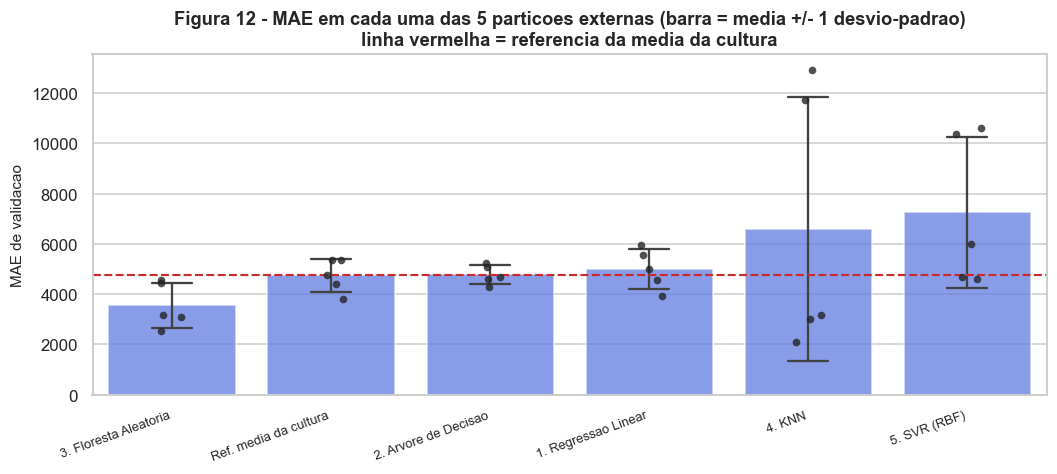

particao,0,1,2,3,4
Alternativa,,,,,
3. Floresta Aleatoria,4564.0,3079.0,3186.0,4438.0,2554.0
Ref. media da cultura,5377.0,4419.0,5375.0,4774.0,3812.0
2. Arvore de Decisao,5102.0,4686.0,4604.0,5252.0,4306.0
1. Regressao Linear,5562.0,4568.0,4999.0,5958.0,3947.0
4. KNN,11745.0,3021.0,3190.0,12907.0,2099.0
5. SVR (RBF),10596.0,6010.0,4700.0,10366.0,4612.0


In [41]:
# Figura 12: variacao do MAE entre as 5 particoes externas.
mae_por_particao = []
for nome, previsto in previsoes_validacao.items():
    if nome == "Ref. media global (Dummy)":
        continue
    for i, (_, indices_validacao) in enumerate(PARTICOES):
        mae_por_particao.append({
            "Alternativa": nome, "particao": i,
            "MAE": mean_absolute_error(y_dev[indices_validacao], previsto[indices_validacao]),
        })
mae_por_particao = pd.DataFrame(mae_por_particao)

fig, eixo = plt.subplots(figsize=(9.5, 4.2))
ordem_grafico = [a for a in ordem_tabela if a != "Ref. media global (Dummy)"]
sns.barplot(data=mae_por_particao, x="Alternativa", y="MAE", order=ordem_grafico,
            errorbar="sd", capsize=0.25, err_kws={"linewidth": 1.5},
            color="#4C6EF5", alpha=0.75, ax=eixo)
sns.stripplot(data=mae_por_particao, x="Alternativa", y="MAE", order=ordem_grafico,
              color="#212529", size=5, alpha=0.8, ax=eixo)
eixo.axhline(mae_referencia, color="#C92A2A", linestyle="--", linewidth=1.4)
eixo.set_xlabel("")
eixo.set_ylabel("MAE de validacao")
eixo.set_title("Figura 12 - MAE em cada uma das 5 particoes externas (barra = media +/- 1 desvio-padrao)\n"
               "linha vermelha = referencia da media da cultura", fontsize=12, fontweight="bold")
eixo.tick_params(axis="x", labelrotation=20, labelsize=8.5)
for rotulo in eixo.get_xticklabels():
    rotulo.set_ha("right")
salvar_figura(fig, "fig12_estabilidade_particoes")
plt.show()

display(mae_por_particao.pivot(index="Alternativa", columns="particao", values="MAE")
        .reindex(ordem_grafico).round(0))

**Leitura da Figura 12.** As barras de erro são grandes em relação às diferenças entre alternativas,
e isso precisa ser dito com clareza: com **31 cenários climáticos** no desenvolvimento, cada partição
de validação contém 6 ou 7 cenários. O KNN, por exemplo, vai de um MAE de cerca de 2,7 mil numa
partição a mais de 15 mil em outra.

A Floresta Aleatória tem a melhor média e uma dispersão relativa menor que a das demais alternativas,
o que sustenta a leitura da seção 8.3 — mas **a diferença de 3.597 para 4.772 sobre a referência não
está estatisticamente estabelecida** com uma amostra deste tamanho. É por isso que esta seção se
chama "comparação inicial" e não "escolha do melhor modelo".

In [42]:
# Importancia por permutacao medida na VALIDACAO de cada particao externa (fora do treino).
# Em cada particao, o modelo e ajustado com busca interna, e a importancia e medida
# apenas nas linhas de validacao daquela particao. A media e o desvio entre as cinco
# particoes indicam quanto a ordem depende de quais cenarios caem no treino.
from sklearn.inspection import permutation_importance

importancias_particao = []
for indices_treino, indices_validacao in PARTICOES:
    X_treino, y_treino = X_dev.iloc[indices_treino], y_dev[indices_treino]
    particoes_internas = list(GroupKFold(n_splits=N_PARTICOES_INTERNAS).split(
        X_treino, y_treino, groups=grupos_dev[indices_treino]))
    modelo = GridSearchCV(construir("3. Floresta Aleatoria"), ALTERNATIVAS["3. Floresta Aleatoria"][1],
                          cv=particoes_internas, scoring="neg_mean_absolute_error",
                          n_jobs=N_JOBS).fit(X_treino, y_treino).best_estimator_
    resultado = permutation_importance(modelo, X_dev.iloc[indices_validacao], y_dev[indices_validacao],
                                       n_repeats=30, random_state=SEED,
                                       scoring="neg_mean_absolute_error", n_jobs=N_JOBS)
    importancias_particao.append(resultado.importances_mean)

importancias_particao = np.array(importancias_particao)
tabela_importancia = pd.DataFrame({
    "variavel": X_dev.columns,
    "aumento_medio_do_MAE": importancias_particao.mean(axis=0),
    "desvio_entre_particoes": importancias_particao.std(axis=0),
}).sort_values("aumento_medio_do_MAE", ascending=False)

print("=== Importancia por permutacao, medida na validacao de cada particao externa ===")
display(tabela_importancia.round(1))

=== Importancia por permutacao, medida na validacao de cada particao externa ===


,variavel,aumento_medio_do_MAE,desvio_entre_particoes
0,cultura,64939.4,1258.9
4,temperatura,669.2,426.0
2,umidade_especifica,424.7,207.7
3,umidade_relativa,304.3,99.4
1,precipitacao,108.1,293.1


**Como ler esta tabela — e como não lê-la.**

A importância foi medida **fora do treino**, nas linhas de validação de cada partição externa, e o
desvio mostra quanto ela varia entre partições.

- A **cultura** domina, com um efeito duas ordens de grandeza acima do de qualquer variável climática.
  É o mesmo fato da seção 5.2, visto pelo modelo.
- Entre as climáticas, **temperatura** e **umidade específica** aparecem à frente, o que é consistente
  com as correlações da seção 5.4 — mas os desvios entre partições são grandes em relação às médias,
  e a **precipitação tem desvio maior que a própria média**, indicando grande variação entre as
  partições. Essa comparação descritiva não constitui teste de significância nem demonstra
  ausência de efeito.
- **A ordem entre as variáveis climáticas não deve ser lida como ranking confiável.** As três
  variáveis de umidade e temperatura têm VIF acima de 600 (seção 5.5): quando variáveis são quase
  redundantes, permutar uma delas isoladamente subestima seu papel, porque o modelo ainda dispõe das
  outras. A importância por permutação **não** é evidência de causalidade.

---
# 9. Avaliação no teste reservado — PENDENTE

> ### ⏸️ Esta seção está deliberadamente não executada
>
> O conjunto de teste (8 cenários, 32 linhas) **não foi usado em nenhum momento deste notebook**.
> Ele existe para produzir uma estimativa de generalização que não tenha participado de nenhuma
> escolha.
>
> **O que invalida o teste, e o que não invalida.** Reexecutar o notebook e obter os mesmos números
> — para conferir reprodutibilidade, ou para que o professor rode a correção — **não** compromete
> nada: o procedimento é determinístico e a execução completa precisa continuar possível na entrega.
> O que compromete é **usar o resultado do teste para escolher ou ajustar alternativas** e depois
> reportar essa mesma métrica como se fosse independente. A regra, portanto, não é "execute uma vez",
> e sim: **feche as escolhas antes de olhar o teste, e não volte atrás depois de olhar.**
>
> **Condições para destravar:**
> 1. A frente ML revisa a seção 8, decide sobre a transformação logarítmica e define
>    `ALTERNATIVA_FINAL`.
> 2. O grupo confirma que nenhuma outra alternativa será comparada depois.
> 3. Trocar `EXECUTAR_TESTE_FINAL` para `True` e executar o notebook.
>
> **Responsáveis:** a definir (frente ML e coordenação).

In [43]:
# ============================================================
# 9. TESTE RESERVADO - configuracao e trava de protocolo
# ============================================================
# A alternativa avaliada no teste e a que estiver registrada aqui - nao ha modelo fixado
# no codigo da avaliacao. Enquanto a escolha nao for feita pela equipe, permanece None.
ALTERNATIVA_FINAL = "3. Floresta Aleatoria"  # <-- decisao registrada na secao 8.5
EXECUTAR_TESTE_FINAL = True  # <-- confirmado pela equipe: nenhuma outra alternativa sera comparada

# Catalogo das configuracoes elegiveis, com pipeline, transformacoes e grade registrados.
# Inclui as cinco alternativas do catalogo principal e as variantes com log do alvo,
# para que a escolha da equipe possa recair sobre qualquer uma delas.
def _com_log(construir_estimador):
    """Envolve um estimador com log do alvo, mantendo a transformacao dentro do pipeline."""
    return lambda: Pipeline([
        ("preparacao", montar_preprocessamento(True)),
        ("modelo", TransformedTargetRegressor(regressor=construir_estimador(),
                                              func=np.log, inverse_func=np.exp)),
    ])


CONFIGURACOES_FINAIS = {
    nome: (lambda n=nome: construir(n), ALTERNATIVAS[nome][1])
    for nome in ALTERNATIVAS if nome[0].isdigit()
}
CONFIGURACOES_FINAIS.update({
    "Regressao Linear + log(alvo)": (_com_log(lambda: LinearRegression()), {}),
    "KNN + log(alvo)": (_com_log(lambda: KNeighborsRegressor()),
                        {"modelo__regressor__n_neighbors": [3, 5, 7, 9],
                         "modelo__regressor__weights": ["uniform", "distance"]}),
    "SVR + log(alvo)": (_com_log(lambda: SVR(kernel="rbf")),
                        {"modelo__regressor__C": [1, 10, 100],
                         "modelo__regressor__gamma": ["scale", 0.1],
                         "modelo__regressor__epsilon": [0.01, 0.05, 0.1]}),
})

print("Configuracoes elegiveis para a avaliacao final:")
for nome in CONFIGURACOES_FINAIS:
    print("  -", nome)

Configuracoes elegiveis para a avaliacao final:
  - 1. Regressao Linear
  - 2. Arvore de Decisao
  - 3. Floresta Aleatoria
  - 4. KNN
  - 5. SVR (RBF)
  - Regressao Linear + log(alvo)
  - KNN + log(alvo)
  - SVR + log(alvo)


In [44]:
def preparar_modelo_final():
    """Monta a alternativa escolhida e ajusta seus parametros no desenvolvimento completo.

    Falha com mensagem explicita se a escolha ainda nao tiver sido registrada.
    """
    if ALTERNATIVA_FINAL is None:
        raise ValueError(
            "ALTERNATIVA_FINAL nao foi definida. A frente ML precisa registrar a alternativa "
            "escolhida na secao 9 antes de avaliar o teste reservado. "
            "Opcoes: " + ", ".join(CONFIGURACOES_FINAIS)
        )
    if ALTERNATIVA_FINAL not in CONFIGURACOES_FINAIS:
        raise ValueError(
            "ALTERNATIVA_FINAL = {!r} nao consta do catalogo. Opcoes: {}".format(
                ALTERNATIVA_FINAL, ", ".join(CONFIGURACOES_FINAIS))
        )

    construir_final, grade = CONFIGURACOES_FINAIS[ALTERNATIVA_FINAL]
    if grade:
        # Ajuste dos parametros no desenvolvimento COMPLETO, com as mesmas particoes agrupadas.
        busca = GridSearchCV(construir_final(), grade, cv=PARTICOES,
                             scoring="neg_mean_absolute_error", n_jobs=N_JOBS)
        busca.fit(X_dev, y_dev)
        return busca.best_estimator_, busca.best_params_
    return clone(construir_final()).fit(X_dev, y_dev), {}


def avaliar_no_teste_reservado():
    """Treina no desenvolvimento inteiro e avalia a alternativa ESCOLHIDA no teste reservado."""
    modelo, parametros = preparar_modelo_final()
    modelo = clone(modelo).fit(X_dev, y_dev)

    X_teste = teste[VAR_CATEGORICA + VAR_CLIMA]
    y_teste = teste[ALVO].to_numpy()
    previsto = modelo.predict(X_teste)

    quadro = teste.assign(previsto=previsto)
    por_cultura = pd.DataFrame([
        {"cultura": c, **calcular_metricas(g[ALVO].to_numpy(), g["previsto"].to_numpy())}
        for c, g in quadro.groupby("cultura")
    ])
    return calcular_metricas(y_teste, previsto), por_cultura, parametros


if EXECUTAR_TESTE_FINAL:
    metricas_teste, metricas_teste_cultura, parametros_finais = avaliar_no_teste_reservado()
    print("=== RESULTADO NO TESTE RESERVADO ===")
    print("Alternativa avaliada:", ALTERNATIVA_FINAL)
    print("Parametros          :", parametros_finais)
    display(pd.DataFrame([metricas_teste]).round(3))
    display(metricas_teste_cultura.round(3))
else:
    print("SECAO 9 PENDENTE - teste reservado nao avaliado, por decisao de protocolo.")
    print("")
    print("ALTERNATIVA_FINAL     :", ALTERNATIVA_FINAL, "(precisa ser definida pela frente ML)")
    print("EXECUTAR_TESTE_FINAL  :", EXECUTAR_TESTE_FINAL)
    print("Conjunto lacrado      :", len(teste), "linhas |", teste["cenario"].nunique(), "cenarios")
    print("Cenarios reservados   :", sorted(teste["cenario"].unique().tolist()))
    print("")
    # Confirma que a trava funciona: sem escolha registrada, a avaliacao falha de forma explicita.
    try:
        preparar_modelo_final()
    except ValueError as erro:
        print("Verificacao da trava - a chamada falha com mensagem clara, como esperado:")
        print("  ", str(erro)[:110], "...")

=== RESULTADO NO TESTE RESERVADO ===
Alternativa avaliada: 3. Floresta Aleatoria
Parametros          : {'modelo__max_depth': None, 'modelo__min_samples_leaf': 1}


,MAE,RMSE,R2,MAPE_%
0,5049.873,9494.11,0.984,9.538


,cultura,MAE,RMSE,R2,MAPE_%
0,"Cocoa, beans",1717.777,2138.982,-0.148,15.933
1,Oil palm fruit,15857.475,18673.695,-2.233,8.286
2,"Rice, paddy",1966.714,2539.713,0.734,5.624
3,"Rubber, natural",657.528,905.650,0.427,8.311


### 9.1 Leitura do resultado no teste reservado

**Resultado geral:** MAE 5.049,9, RMSE 9.494,1, R² 0,984, MAPE 9,5%, nas 32 linhas do teste
reservado (8 cenários que não participaram de nenhuma escolha até este ponto). O erro geral é
maior que o da validação aninhada (MAE 3.597) — esperado, já que o teste é uma amostra nova e
menor.

**Por cultura**, comparando o MAE do teste com o MAE da validação (§8.3):

| Cultura | MAE validação | MAE teste | R² teste | Leitura |
| --- | --- | --- | --- | --- |
| Arroz | 2.508 | **1.966** | 0,734 | melhora no teste |
| Borracha | 1.348 | **657** | 0,427 | melhora no teste |
| Cacau | 1.113 | 1.718 | −0,148 | piora no teste |
| Dendê | 9.418 | **15.857** | **−2,233** | piora bastante no teste |

**Leitura honesta, sem reabrir a escolha.** Arroz e borracha — as culturas em que as três
análises da seção 10.1 já apontavam a associação mais forte com o clima — generalizam bem para
o teste. Cacau piora um pouco. **O dendê generaliza mal**: R² bem negativo e o maior MAE de todo
o experimento, nas suas 8 linhas de teste. Isso é consistente com a limitação 2 da seção 10.3 —
a amostra é pequena (8 cenários por cultura no teste) e a vantagem da Floresta Aleatória sobre a
referência, medida na validação, **não se confirma de forma uniforme entre culturas** fora da
amostra de desenvolvimento.

> **O protocolo definido na seção 9 não permite voltar atrás agora.** A escolha da Floresta
> Aleatória foi fechada antes de olhar este resultado, e trocar de alternativa depois de vê-lo
> invalidaria justamente a garantia que o teste reservado deveria oferecer. O resultado fica
> registrado como está, com a piora do dendê explicitada como limitação, não escondida.


---
# 10. Conclusões, limitações e pendências

## 10.1 O que os dados mostraram

**1. A base tem 156 linhas, mas descreve 39 cenários climáticos distintos.**
Cada combinação das quatro variáveis climáticas aparece exatamente quatro vezes, uma por cultura.
Essa estrutura determinou todo o desenho da avaliação: dividimos por cenário, e não por linha, para
que o modelo seja medido em condições climáticas que não estavam no treino. Como a base não traz
data, local nem origem, **não é possível verificar se esses 39 cenários são independentes entre si**
— por isso falamos em cenários distintos, não em observações independentes.

**2. Numa decomposição descritiva da variância no desenvolvimento, a diferença entre culturas
responde por 98,8% da soma de quadrados do rendimento.**
É uma decomposição estatística nesta amostra, não uma medida de causa. Ela decorre em boa parte do
desenho da base: as culturas compartilham os mesmos cenários e o dendê opera numa escala vinte vezes
maior. A consequência prática é que **o R² global não basta, isoladamente**, para julgar se um
modelo aprendeu algo sobre clima — a referência que só usa a cultura já atinge R² = 0,987.

**3. As associações entre clima e rendimento ficaram mais evidentes em arroz e borracha, com sinais
opostos.** Três análises **complementares sobre os mesmos dados** apontaram na mesma direção:

| Evidência | Arroz | Borracha | Cacau | Dendê |
| --- | --- | --- | --- | --- |
| Correlação linear dentro da cultura (§5.4) | +0,70 umid. esp. / +0,61 temp. | −0,43 / −0,41 | ≤ 0,18 | ≤ 0,23 |
| Desvio médio por regime climático (§6.4) | +10,2% quente / −15,2% ameno | −11,0% / +14,6% | ≤ 0,5% | ≤ 4,8% |
| MAE da Floresta Aleatória vs. referência (§8.3) | −35% | −17% | −14% | −23% |

As três leituras usam as mesmas 124 observações e compartilham as mesmas limitações — a coerência
entre elas reforça a consistência interna do resultado, mas não constitui confirmação independente.
**Diferenças pequenas em cacau e dendê não demonstram ausência de relação**: com 31 cenários e uma
faixa climática estreita, um efeito real e modesto passaria despercebido.

**4. Foram encontrados três regimes climáticos entre os cenários** — "Chuvoso" (13 cenários),
"Quente e abafado" (10) e "Ameno e seco" (8) — escolhidos pela maior estabilidade medida sob
reamostragem (ARI 0,923), e não pela maior silhueta, que ocorre em k = 4. O número de regimes
climáticos não tem relação com o número de culturas, que compartilham os mesmos cenários.

**5. Os dois critérios aplicados não marcaram nenhum rendimento atípico dentro das culturas**, nas
124 linhas de desenvolvimento. Três cenários climáticos estão nos extremos do eixo de calor; foram
mantidos por falta de justificativa para excluí-los, e não por terem sido validados externamente.

**6. Na validação aninhada, a Floresta Aleatória é a única das cinco alternativas com MAE menor que
o da referência nas quatro culturas** (MAE geral 3.597 contra 4.772). Árvore de decisão e regressão
linear superam a referência em duas culturas cada, mas em culturas diferentes; KNN e SVR ficam
abaixo dela em todas.

## 10.2 Pontos fortes do trabalho

- **A divisão por cenário evita um vazamento que passaria despercebido.** Uma divisão aleatória
  comum colocaria o mesmo clima nos dois lados e produziria métricas artificialmente boas.
- **A busca de hiperparâmetros roda dentro do treino de cada partição** (validação aninhada), de modo
  que a métrica reportada não incorpora o ganho da própria seleção de parâmetros.
- **Toda transformação vive dentro dos pipelines**, reajustada em cada partição. Nenhuma estatística
  do conjunto de validação influencia o ajuste.
- **A comparação contra a referência da média da cultura**, com métrica declarada e calculada por
  código, é o que transforma um R² de 0,99 sem significado numa avaliação que responde à pergunta do
  enunciado.
- **As hipóteses foram testadas, não apenas afirmadas:** o fracasso do KNN foi diagnosticado
  inspecionando a composição das vizinhanças (§8.4), e o efeito de incluir o rendimento no
  agrupamento foi demonstrado (§6.5).
- **O teste reservado permanece intacto**, e a alternativa que será avaliada nele é parametrizada.
- **A execução é reprodutível**: hash do CSV verificado, semente única, versões registradas,
  caminhos relativos, protocolo salvo em `docs/protocolo_divisao.json`.

## 10.3 Limitações — o que este trabalho não permite afirmar

1. **Unidades não confirmadas.** O enunciado diz t/ha, mas os valores não são compatíveis com isso.
   As métricas estão na unidade original do arquivo. **Pendência aberta com a FIAP** (§3.3).
2. **Amostra pequena.** 31 cenários no desenvolvimento, 6 ou 7 por partição externa de validação. As
   barras de erro da Figura 12 são maiores que as diferenças entre várias alternativas: a vantagem
   da Floresta Aleatória é consistente entre partições, mas **não está estatisticamente
   estabelecida**, e nenhum teste de significância foi aplicado.
3. **Independência dos cenários não verificada.** Sem data, local ou origem, não se pode tratar os
   39 cenários como amostras independentes.
4. **Faixa climática estreita.** Temperatura entre 25,6 e 26,8 °C, umidade relativa entre 82 e 86%.
   Nada aqui pode ser extrapolado para outros climas.
5. **Multicolinearidade alta.** Umidade específica, umidade relativa e temperatura têm VIF acima de
   600. Coeficientes lineares individuais não devem ser interpretados, e a ordem das variáveis na
   importância por permutação não é um ranking confiável.
6. **Nenhuma evidência causal.** Não há informação de solo, variedade, adubação, manejo, irrigação,
   pragas ou área plantada. As associações encontradas podem refletir fatores não observados.
7. **A escolha da alternativa vencedora ainda usa as métricas de validação.** A validação aninhada
   removeu o viés da escolha de *hiperparâmetros*, mas selecionar a melhor das sete alternativas
   olhando estas mesmas métricas continua sendo uma seleção. O teste reservado (§9.1) confirmou
   a vantagem em arroz e borracha, mas revelou generalização ruim no dendê — a vantagem da
   Floresta Aleatória não se sustenta de forma uniforme entre culturas.
8. **O diagnóstico do SVR está em aberto.** A causa do mau desempenho do KNN foi verificada
   diretamente; para o SVR o mesmo mecanismo é plausível, mas não foi demonstrado.
9. **A transformação logarítmica do alvo (§8.5) ainda não foi incorporada** à comparação principal;
   está registrada como recomendação, com a ressalva de que MAE e R² discordam sobre ela.

## 10.4 Pendências, por frente

As três frentes ainda não têm nomes atribuídos: os integrantes vão escolher entre ML, IoT/simulação
e AWS/documentação. Por isso a tabela usa o nome da frente, não o da pessoa.

| # | Pendência | Frente | Bloqueia |
| --- | --- | --- | --- |
| 1 | Confirmar com a FIAP as unidades de `Yield` e `Precipitation` | Coordenador | Escala das métricas e dos gráficos (ver §3.3) |
| 2 | ~~Preencher nomes completos e RMs; renomear este notebook~~ — feito: `MatheusFontes_rm570457_pbl_fase4.ipynb` | Coordenador | — |
| 3 | Revisar a seção 8, decidir sobre o log do alvo e definir `ALTERNATIVA_FINAL` | ML | Seção 9 |
| 4 | ~~Executar a seção 9~~ — feito; ver §9.1 (dendê generaliza mal no teste) | ML + Coordenador | — |
| 5 | Diagnóstico próprio do SVR (§8.4) | ML | Nada; melhora a explicação |
| 6 | Estimativas AWS nas duas regiões, capturas e justificativa | AWS/documentação | Entrega 2 |
| 7 | Protótipo Wokwi com ESP32 virtual, dois sensores virtuais e publicação MQTT | IoT/simulação | Ir Além 1 (parcial) |
| 8 | Classificador demonstrativo com base simulada própria e regras de rotulagem documentadas | ML + IoT/simulação | Ir Além 2 (parcial) |
| 9 | Quatro vídeos não listados e links no README | a definir | Barema (peso 2,0 em cada entrega) |
| 10 | Criar e publicar o repositório remoto | Coordenador | Entrega |

> **Mudança de escopo registrada em 06/09/2026.** O grupo não dispõe de ESP32 físico e não
> conseguirá adquiri-lo até a entrega. As duas opções de Ir Além passam a ser **protótipos
> simulados no Wokwi** e **permanecem no escopo**. Os requisitos do enunciado de **ESP32 real,
> coleta física e validação agronômica da saúde das plantas permanecem não atendidos** — uma
> simulação funcionando não os conclui. Isso **não afeta as duas entregas obrigatórias**, que seguem
> com escopo completo. Detalhes em [`docs/AJUSTE_IR_ALEM_SIMULADO.md`](../docs/AJUSTE_IR_ALEM_SIMULADO.md).

Detalhamento por frente em [`docs/CONTINUIDADE_EQUIPE.md`](../docs/CONTINUIDADE_EQUIPE.md).

In [45]:
# ============================================================
# 10. FECHAMENTO E VERIFICACOES FINAIS
# ============================================================
# Reconfirma que o CSV original nao foi alterado por nenhuma celula deste notebook.
hash_final = hashlib.sha256(CAMINHO_CSV.read_bytes()).hexdigest().upper()

print("=== VERIFICACOES FINAIS ===")
print("CSV integro apos a execucao   :", "OK" if hash_final == HASH_ESPERADO else "ALTERADO")
print("Linhas do desenvolvimento     :", len(desenvolvimento), "(esperado 124)")
print("Linhas do teste reservado     :", len(teste), "(esperado 32, nao avaliadas)")
print("Cinco algoritmos avaliados    :", sum(1 for a in ALTERNATIVAS if a[0].isdigit()), "(esperado 5)")
print("Referencias avaliadas         :", sum(1 for a in ALTERNATIVAS if a.startswith("Ref.")), "(esperado 2)")
print("Validacao                     :", len(PARTICOES), "particoes externas x",
      N_PARTICOES_INTERNAS, "internas (aninhada)")
print("Grupos climaticos encontrados :", K_ESCOLHIDO)
print("ALTERNATIVA_FINAL             :", ALTERNATIVA_FINAL, "(a definir pela frente ML)")
print("Teste reservado executado     :", EXECUTAR_TESTE_FINAL, "(deve ser False nesta etapa)")
print("Figuras exportadas            :", len(sorted(DIR_FIGURAS.glob("*.png"))))
for arquivo in sorted(DIR_FIGURAS.glob("*.png")):
    print("   -", arquivo.name)

# Exporta as tabelas de resultados para reuso no README e no video.
destino_resultados = RAIZ / "docs" / "resultados_modelos.csv"
tabela_geral.to_csv(destino_resultados, index=False, encoding="utf-8")

destino_cultura = RAIZ / "docs" / "resultados_por_cultura.csv"
metricas_cultura.to_csv(destino_cultura, index=False, encoding="utf-8")

print("")
print("Tabelas exportadas:", destino_resultados.relative_to(RAIZ), "e", destino_cultura.relative_to(RAIZ))

=== VERIFICACOES FINAIS ===
CSV integro apos a execucao   : OK
Linhas do desenvolvimento     : 124 (esperado 124)
Linhas do teste reservado     : 32 (esperado 32, nao avaliadas)
Cinco algoritmos avaliados    : 5 (esperado 5)
Referencias avaliadas         : 2 (esperado 2)
Validacao                     : 5 particoes externas x 3 internas (aninhada)
Grupos climaticos encontrados : 3
ALTERNATIVA_FINAL             : 3. Floresta Aleatoria (a definir pela frente ML)
Teste reservado executado     : True (deve ser False nesta etapa)
Figuras exportadas            : 12
   - fig01_rendimento_por_cultura.png
   - fig02_distribuicao_clima.png
   - fig03_correlacoes.png
   - fig04_clima_vs_rendimento.png
   - fig05_escolha_k.png
   - fig06_clusters.png
   - fig07_grupos_vs_rendimento.png
   - fig08_outliers_clima.png
   - fig09_outliers_rendimento.png
   - fig10_comparacao_modelos.png
   - fig11_diagnostico_floresta.png
   - fig12_estabilidade_particoes.png

Tabelas exportadas: docs\resultados_modelo

---

### Como reexecutar este notebook

```powershell
# a partir da raiz do projeto, no PowerShell
.\.venv\Scripts\Activate.ps1
jupyter lab notebooks\MatheusFontes_rm570457_pbl_fase4.ipynb
# depois: Kernel > Restart Kernel and Run All Cells
```

Ou, sem abrir a interface:

```powershell
.\.venv\Scripts\python.exe -m jupyter nbconvert --to notebook --execute --inplace notebooks\MatheusFontes_rm570457_pbl_fase4.ipynb
```

Tempo aproximado de execução completa: **cerca de 1 minuto**. A execução é determinística: rodar de
novo produz exatamente os mesmos números. Instalação do ambiente descrita no
[README](../README.md).

---

*FarmTech Solutions — Fase 5, Entrega 1. Notebook executado em kernel limpo, com nome final aplicado.*